# This same note is in notes.md in the same directory to this jupyter notebook.

## Overview (with a few extension options)

* Regression vs. Classification:
  * **Pros**: regression uses the margin of victory, so a 3–0 and 1–0 are not treated as equally strong wins.
  * **Cons**: soccer scores are **low-count, discrete, noisy, and heavily concentrated near 0**, so plain regression is a bit less natural than classification.
* **Primary regression approach**: predict **goal difference**; *vs.* **Optional stronger extension**: predict the **two team scores separately** with count models, then derive win/draw/loss from those
* Symmetric vs. asymmetric threshold

## Models

I used this following set:

1. **Ridge regression**
   Best baseline. Stable for small data, easy to interpret, good when sample size is limited.
2. **Elastic Net / Lasso**
   Useful if we have many correlated engineered features (we probably do because Tony and Oge work on feature engineering) and want some regularization / feature selection.
3. **Random Forest Regressor**
   Captures nonlinearity and interactions without much preprocessing.
4. **XGBoost Regressor**
   Probably the strongest nonlinear candidate, especially since Mingjie already uses XGBoost on the classification side.

That gives us a very nice comparison:

- linear regularized baseline
- sparse/regularized linear variant
- bagged tree model
- boosted tree model

## Evaluation

I used both **regression** metrics and **converted classification** metrics.

### Regression-side metrics

These tell whether the model predicts score margin well:

* **MAE** on goal difference
* **RMSE** on goal difference

I would make **MAE** the main one because soccer score margins are small and MAE is easier to interpret.

### Converted 3-class metrics

After applying threshold *t*, compare fairly to Mingjie's classification approach:

* **macro F1**
* **accuracy**
* confusion matrix
* optionally macro recall

This is crucial, because even if regression has decent MAE, it may still map poorly into draw/upset/win classes.

## Comparison with Mingjie's classifier

I used the **same split and same feature matrix entry point** (`fav_df`) and only changed:

* target $y$
* estimator type
* decision rule from continuous output to 3 classes

That makes the comparison clean:

* same preprocessing base
* same temporal split
* same evaluation period
* same engineered features

This is exactly in accordance with the project design of comparing modeling strategies on the same underlying data.

## Potential Weakness

- regression to score difference may under-predict draws

A continuous regressor tends to shrink predictions toward the mean. That can be okay, but it means:

* many predictions may cluster around small positive values
* the threshold may become the main determinant of draw frequency

That is not necessarily bad, but it means threshold tuning is extremely important.

## Better Alternative

### model each team's goals separately

Predict:

* favored goals
* underdog goals

with **Poisson regression** or another count model, then derive:

* predicted goal difference
* predicted class
* even draw probability

Why this is attractive:

* goals are nonnegative counts
* soccer score distributions are low-count
* draw probability emerges more naturally

This is more principled than plain regression on difference.


# Part 0: Import Libraries

In [1]:
# ============================================================
# Part 1
# ============================================================

import sqlite3

from pathlib import Path

import numpy as np
import pandas as pd

# ============================================================
# Part 2
# ============================================================

# import numpy as np
# import pandas as pd

import matplotlib.pyplot as plt

# ============================================================
# Part 2.5
# ============================================================

# import numpy as np
# import pandas as pd

# ============================================================
# Part 3
# ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ============================================================
# Part 4
# ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# from sklearn.model_selection import LeaveOneGroupOut

# ============================================================
# Part 5
# ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor

# from sklearn.impute import SimpleImputer
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
# from sklearn.pipeline import Pipeline

# ============================================================
# Part 6
# ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.base import clone
# from sklearn.impute import SimpleImputer
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
# from sklearn.pipeline import Pipeline

# ============================================================
# Part 7
# ============================================================

# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.base import clone
# from sklearn.metrics import (
#    accuracy_score,
#    f1_score,
#    confusion_matrix,
#    classification_report,
# )
# from sklearn.model_selection import LeaveOneGroupOut

# Part 1: Build `fav_df`

For Part 1, I did:

- build the regression target
- reuse Mingjie’s `fav_df`
- define the feature matrix
- create the same temporal train/holdout split
- run a few sanity checks on target distribution

I have **not** trained any model yet.

## 0. Paths

In [2]:
# BUILD fav_df (minimal preprocessing block for regression work)
# Based on Mingjie's notebook, but stripped down to only what is needed

# 0. PATHS -- EDIT THESE IF NEEDED
# I added one more ../ since I created new directory
BASE = Path("../../../")  # <-- change this if needed
DB_PATH = BASE / "data/raw/worldcup/data-sqlite/worldcup.db"
ELO_PATH = BASE / "data/raw/elo_ratings.csv"

assert DB_PATH.is_file(), f"SQLite DB not found: {DB_PATH}"
assert ELO_PATH.is_file(), f"Elo CSV not found: {ELO_PATH}"

## 1. Load Raw Tables

In [3]:
con = sqlite3.connect(DB_PATH)


def _sql(q):
    return pd.read_sql_query(q, con)


matches = _sql("SELECT * FROM matches")
tournaments = _sql("SELECT * FROM tournaments")
teams = _sql("SELECT * FROM teams")
stadiums = _sql("SELECT * FROM stadiums")
team_appearances = _sql("SELECT * FROM team_appearances")
squads = _sql("SELECT * FROM squads")
players = _sql("SELECT * FROM players")
manager_appointments = _sql("SELECT * FROM manager_appointments")
managers = _sql("SELECT * FROM managers")
manager_appearances = _sql("SELECT * FROM manager_appearances")
referee_appearances = _sql("SELECT * FROM referee_appearances")

# Outcome flags used later
mdb = _sql("SELECT match_id, home_team_win, away_team_win, draw FROM matches")

con.close()

elo_raw = pd.read_csv(ELO_PATH)

print("Loaded raw tables:")
print("matches:", matches.shape)
print("tournaments:", tournaments.shape)
print("teams:", teams.shape)
print("team_appearances:", team_appearances.shape)
print("squads:", squads.shape)
print("players:", players.shape)
print("elo_raw:", elo_raw.shape)

Loaded raw tables:
matches: (1248, 28)
tournaments: (30, 17)
teams: (88, 11)
team_appearances: (2496, 17)
squads: (13843, 6)
players: (10401, 12)
elo_raw: (17200, 17)


## 2. Date Parsing + Tournament Year Info

In [4]:
tournaments["start_dt"] = pd.to_datetime(
    pd.to_numeric(tournaments["start_date"], errors="coerce"),
    unit="D",
    origin="unix",
    errors="coerce",
)
matches["match_dt"] = pd.to_datetime(
    pd.to_numeric(matches["match_date"], errors="coerce"),
    unit="D",
    origin="unix",
    errors="coerce",
)

tourn_year = tournaments[["tournament_id", "year", "host_country", "start_dt"]].copy()
matches = matches.merge(tourn_year, on="tournament_id", how="left", suffixes=("", "_t"))

## 3. Base Match Table

In [5]:
base = matches[
    [
        "match_id",
        "tournament_id",
        "year",
        "host_country",
        "home_team_id",
        "away_team_id",
        "match_dt",
        "stage_name",
        "group_name",
        "group_stage",
        "knockout_stage",
        "replayed",
        "replay",
        "stadium_id",
        "home_team_win",
    ]
].copy()

base["y_win"] = base["home_team_win"].astype("Int64").fillna(0).astype(int)

th = teams.rename(columns={c: f"home_{c}" for c in teams.columns if c != "team_id"})
ta = teams.rename(columns={c: f"away_{c}" for c in teams.columns if c != "team_id"})

base = base.merge(th, left_on="home_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(ta, left_on="away_team_id", right_on="team_id", how="left").drop(
    columns=["team_id"]
)
base = base.merge(stadiums, on="stadium_id", how="left", suffixes=("", "_stadium"))


def _norm(s):
    return s.astype(str).str.strip().str.lower().str.replace(" ", "", regex=False)


base["feat_same_confederation"] = (
    base["home_confederation_id"] == base["away_confederation_id"]
).astype(int)

base["feat_home_is_host_nation"] = (
    _norm(base["home_team_name"]) == _norm(base["host_country"])
).astype(int)
base["feat_away_is_host_nation"] = (
    _norm(base["away_team_name"]) == _norm(base["host_country"])
).astype(int)

print("base shape after match/team/stadium merge:", base.shape)

base shape after match/team/stadium merge: (1248, 45)


## 4. Historical Team Features

In [6]:
ta_hist = team_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
ta_hist = ta_hist.merge(
    matches[["match_id", "knockout_stage", "group_stage"]],
    on="match_id",
    how="left",
    suffixes=("", "_m"),
)

ALPHA, BETA = 2.0, 2.0


def shrink_win_rate(w, n, a=ALPHA, b=BETA):
    return (w + a) / (n + a + b) if n > 0 else a / (a + b)


def prior_team_stats(team_id, before_year):
    sub = ta_hist[(ta_hist["team_id"] == team_id) & (ta_hist["year"] < before_year)]
    if sub.empty:
        return dict(
            n_tournaments=0,
            n_matches=0,
            wins=0,
            draws=0,
            losses=0,
            goal_diff_sum=0,
            ko_matches=0,
            ko_wins=0,
            pso_matches=0,
            pso_wins=0,
            et_matches=0,
            tournaments_with_ko_game=0,
        )

    ko = sub[sub["knockout_stage"] == 1]
    pso = sub[sub["penalty_shootout"] == 1]

    return dict(
        n_tournaments=sub["tournament_id"].nunique(),
        n_matches=len(sub),
        wins=int(sub["win"].sum()),
        draws=int(sub["draw"].sum()),
        losses=int(sub["lose"].sum()),
        goal_diff_sum=float((sub["goals_for"] - sub["goals_against"]).sum()),
        ko_matches=len(ko),
        ko_wins=int(ko["win"].sum()),
        pso_matches=len(pso),
        pso_wins=int((pso["penalties_for"] > pso["penalties_against"]).sum()),
        et_matches=int(sub["extra_time"].sum()),
        tournaments_with_ko_game=len(set(ko["tournament_id"].unique())),
    )


years = sorted(base["year"].dropna().unique())
all_tids = pd.unique(
    np.concatenate([base["home_team_id"].values, base["away_team_id"].values])
)

cache = {
    (tid, int(y)): prior_team_stats(tid, int(y)) for tid in all_tids for y in years
}


def attach_hist(df, prefix, team_col):
    rows = [cache[(r[team_col], int(r["year"]))] for _, r in df.iterrows()]
    h = pd.DataFrame(rows).add_prefix(f"{prefix}hist_")
    pfx = f"{prefix}hist_"

    h[f"{pfx}win_rate_shrunk"] = [
        shrink_win_rate(int(w), int(n))
        for w, n in zip(h[f"{pfx}wins"], h[f"{pfx}n_matches"])
    ]
    h[f"{pfx}goal_diff_per_match"] = np.where(
        h[f"{pfx}n_matches"] > 0,
        h[f"{pfx}goal_diff_sum"] / h[f"{pfx}n_matches"],
        np.nan,
    )
    h[f"{pfx}ko_win_rate_shrunk"] = [
        shrink_win_rate(int(kw), int(km))
        for kw, km in zip(h[f"{pfx}ko_wins"], h[f"{pfx}ko_matches"])
    ]
    h[f"{pfx}pso_win_rate_shrunk"] = [
        shrink_win_rate(int(pw), int(pm)) if pm > 0 else np.nan
        for pw, pm in zip(h[f"{pfx}pso_wins"], h[f"{pfx}pso_matches"])
    ]
    h[f"{pfx}et_rate"] = np.where(
        h[f"{pfx}n_matches"] > 0,
        h[f"{pfx}et_matches"] / h[f"{pfx}n_matches"],
        np.nan,
    )
    h[f"{pfx}frac_tournaments_reached_ko"] = np.where(
        h[f"{pfx}n_tournaments"] > 0,
        h[f"{pfx}tournaments_with_ko_game"] / h[f"{pfx}n_tournaments"],
        np.nan,
    )
    return pd.concat([df.reset_index(drop=True), h], axis=1)


base = attach_hist(base, "home_", "home_team_id")
base = attach_hist(base, "away_", "away_team_id")

base["feat_hist_win_rate_diff"] = (
    base["home_hist_win_rate_shrunk"] - base["away_hist_win_rate_shrunk"]
)
base["feat_hist_goal_diff_per_match_diff"] = (
    base["home_hist_goal_diff_per_match"] - base["away_hist_goal_diff_per_match"]
)

print("base shape after historical team stats:", base.shape)

base shape after historical team stats: (1248, 83)


## 5. Win Rate *vs.* Opponent Confederation

In [7]:
opp_conf = teams[["team_id", "confederation_id"]].rename(
    columns={"team_id": "opponent_id", "confederation_id": "opponent_confederation_id"}
)
ta_oc = ta_hist.merge(opp_conf, on="opponent_id", how="left")


def rate_vs_conf(team_id, before_year, opp_conf_id):
    if pd.isna(opp_conf_id):
        return np.nan
    sub = ta_oc[
        (ta_oc["team_id"] == team_id)
        & (ta_oc["year"] < before_year)
        & (ta_oc["opponent_confederation_id"] == opp_conf_id)
    ]
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_hist_win_rate_vs_away_conf"] = [
    rate_vs_conf(h, int(y), c)
    for h, y, c in zip(
        base["home_team_id"], base["year"], base["away_confederation_id"]
    )
]
base["feat_away_hist_win_rate_vs_home_conf"] = [
    rate_vs_conf(a, int(y), c)
    for a, y, c in zip(
        base["away_team_id"], base["year"], base["home_confederation_id"]
    )
]

print("Added confederation matchup features.")

Added confederation matchup features.


## 6. Squad Features

In [8]:
sq = squads.merge(tourn_year[["tournament_id", "year", "start_dt"]], on="tournament_id")
sq = sq.merge(players, on="player_id", how="left")
sq["birth_dt"] = pd.to_datetime(sq["birth_date"], errors="coerce")

pyt = sq[["player_id", "tournament_id", "year"]].drop_duplicates()
prior_rows = []
for (pid, y), g in pyt.groupby(["player_id", "year"]):
    n_prior = pyt[(pyt["player_id"] == pid) & (pyt["year"] < y)][
        "tournament_id"
    ].nunique()
    prior_rows.append({"player_id": pid, "year": y, "prior_wc_played": n_prior})
prior_wc = pd.DataFrame(prior_rows)

sq = sq.merge(prior_wc, on=["player_id", "year"], how="left")
sq["age_at_tournament"] = (sq["start_dt"] - sq["birth_dt"]).dt.days / 365.25

for col in ["goal_keeper", "defender", "midfielder", "forward"]:
    sq[col] = sq[col].fillna(0).astype(int)


def squad_row(g):
    return dict(
        n_players=len(g),
        age_mean=g["age_at_tournament"].mean(),
        age_median=g["age_at_tournament"].median(),
        age_std=g["age_at_tournament"].std(),
        age_min=g["age_at_tournament"].min(),
        age_max=g["age_at_tournament"].max(),
        n_gk=int(g["goal_keeper"].sum()),
        n_df=int(g["defender"].sum()),
        n_mf=int(g["midfielder"].sum()),
        n_fw=int(g["forward"].sum()),
        prior_wc_mean=g["prior_wc_played"].mean(),
        prior_wc_median=g["prior_wc_played"].median(),
        share_any_prior_wc=(g["prior_wc_played"] > 0).mean(),
        share_ge2_prior_wc=(g["prior_wc_played"] >= 2).mean(),
    )


squad_records = [
    {"tournament_id": tid, "team_id": tmid, **squad_row(g)}
    for (tid, tmid), g in sq.groupby(["tournament_id", "team_id"])
]
squad_feats = pd.DataFrame(squad_records)

overlap_records = []
for team_id, g in sq.groupby("team_id"):
    g = g.sort_values("year")
    years_order = g["year"].unique()
    prev_players = None

    for y in years_order:
        cur = set(g.loc[g["year"] == y, "player_id"].unique())
        if prev_players is not None:
            inter = len(cur & prev_players)
            uni = len(cur | prev_players)
            overlap_records.append(
                dict(
                    team_id=team_id,
                    year=y,
                    squad_jaccard_vs_prev_wc=inter / uni if uni else np.nan,
                    squad_overlap_count_vs_prev_wc=inter,
                )
            )
        prev_players = cur

overlap_df = pd.DataFrame(overlap_records)

squad_feats = squad_feats.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id", how="left"
)
squad_feats = squad_feats.merge(overlap_df, on=["team_id", "year"], how="left")


def _squad_side(sf, prefix, team_col):
    sf2 = sf.rename(
        columns={
            c: f"{prefix}squad_{c}"
            for c in sf.columns
            if c not in ("tournament_id", "team_id", "year")
        }
    )
    sf2 = sf2.rename(columns={"team_id": team_col})
    sf2 = sf2.drop(columns=["year"], errors="ignore")
    return sf2


base = base.merge(
    _squad_side(squad_feats, "home_", "home_team_id"),
    on=["tournament_id", "home_team_id"],
    how="left",
)
base = base.merge(
    _squad_side(squad_feats, "away_", "away_team_id"),
    on=["tournament_id", "away_team_id"],
    how="left",
)

base["feat_squad_age_mean_diff"] = (
    base["home_squad_age_mean"] - base["away_squad_age_mean"]
)
base["feat_squad_prior_wc_mean_diff"] = (
    base["home_squad_prior_wc_mean"] - base["away_squad_prior_wc_mean"]
)

print("base shape after squad features:", base.shape)

base shape after squad features: (1248, 119)


## 7. Manager Features

In [9]:
ma = manager_appointments.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
)
ma = ma.merge(managers, on="manager_id", how="left")
ma_pick = ma.sort_values("manager_id").drop_duplicates(
    subset=["tournament_id", "team_id"], keep="first"
)


def _mgr_side(prefix, side_col):
    cols = {
        "manager_id": f"{prefix}manager_id",
        "country_name": f"{prefix}manager_country_name",
        "female": f"{prefix}manager_female",
    }
    df = ma_pick.rename(columns=cols)
    df = df.rename(columns={"team_id": side_col})
    return df[
        [
            "tournament_id",
            side_col,
            f"{prefix}manager_id",
            f"{prefix}manager_country_name",
            f"{prefix}manager_female",
        ]
    ]


base = base.merge(
    _mgr_side("home_", "home_team_id"),
    on=["tournament_id", "home_team_id"],
    how="left",
)
base = base.merge(
    _mgr_side("away_", "away_team_id"),
    on=["tournament_id", "away_team_id"],
    how="left",
)

base["feat_home_manager_local"] = (
    _norm(base["home_manager_country_name"]) == _norm(base["home_team_name"])
).astype(int)
base["feat_away_manager_local"] = (
    _norm(base["away_manager_country_name"]) == _norm(base["away_team_name"])
).astype(int)

mgr_tourneys = (
    ma_pick[["manager_id", "tournament_id", "year"]]
    .drop_duplicates()
    .sort_values(["manager_id", "year"])
)

mgr_prior_rows = []
for mid, g in mgr_tourneys.groupby("manager_id"):
    for i, (_, r) in enumerate(g.iterrows()):
        mgr_prior_rows.append(
            {
                "manager_id": mid,
                "tournament_id": r["tournament_id"],
                "mgr_n_prior_wc": i,
            }
        )
mgr_prior_df = pd.DataFrame(mgr_prior_rows)

for side in ["home", "away"]:
    tmp = mgr_prior_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "mgr_n_prior_wc": f"{side}_mgr_n_prior_wc",
        }
    )
    base = base.merge(
        tmp[[f"{side}_manager_id", "tournament_id", f"{side}_mgr_n_prior_wc"]],
        on=[f"{side}_manager_id", "tournament_id"],
        how="left",
    )

mapp = manager_appearances.merge(
    tourn_year[["tournament_id", "year"]], on="tournament_id"
).merge(
    team_appearances[["tournament_id", "match_id", "team_id", "win"]],
    on=["tournament_id", "match_id", "team_id"],
    how="left",
)


def mgr_hist_win_rate(manager_id, before_year):
    sub = mapp[(mapp["manager_id"] == manager_id) & (mapp["year"] < before_year)]
    sub = sub.dropna(subset=["win"])
    return shrink_win_rate(int(sub["win"].sum()), len(sub)) if not sub.empty else np.nan


base["feat_home_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["home_manager_id"], base["year"])
]
base["feat_away_mgr_hist_win_rate_shrunk"] = [
    mgr_hist_win_rate(m, int(y)) if pd.notna(m) else np.nan
    for m, y in zip(base["away_manager_id"], base["year"])
]

streak_rows = []
for (mid, tid), g in ma_pick.sort_values("year").groupby(["manager_id", "team_id"]):
    g = g.drop_duplicates(subset=["tournament_id", "year"]).sort_values("year")
    yrs = g["year"].astype(int).tolist()
    tids = g["tournament_id"].tolist()
    run = 0
    for i, y in enumerate(yrs):
        run = (run + 1) if (i == 0 or y - yrs[i - 1] in (1, 4)) else 1
        streak_rows.append(
            {
                "manager_id": mid,
                "team_id": tid,
                "tournament_id": tids[i],
                "mgr_consecutive_wc_with_team": run,
            }
        )
streak_df = pd.DataFrame(streak_rows)

for side in ["home", "away"]:
    tmp = streak_df.rename(
        columns={
            "manager_id": f"{side}_manager_id",
            "team_id": f"{side}_team_id",
            "mgr_consecutive_wc_with_team": f"{side}_mgr_consecutive_wc_with_team",
        }
    )
    base = base.merge(
        tmp[
            [
                f"{side}_manager_id",
                f"{side}_team_id",
                "tournament_id",
                f"{side}_mgr_consecutive_wc_with_team",
            ]
        ],
        on=[f"{side}_manager_id", f"{side}_team_id", "tournament_id"],
        how="left",
    )

print("base shape after manager features:", base.shape)

base shape after manager features: (1248, 133)


## 8. Schedule / Context Features

In [10]:
sched = matches[
    ["match_id", "tournament_id", "home_team_id", "away_team_id", "match_dt", "year"]
].copy()

long_sched = pd.concat(
    [
        sched.rename(
            columns={"home_team_id": "team_id", "away_team_id": "opponent_id"}
        ),
        sched.rename(
            columns={"away_team_id": "team_id", "home_team_id": "opponent_id"}
        ),
    ],
    ignore_index=True,
).sort_values(["tournament_id", "team_id", "match_dt", "match_id"])

long_sched["prev_match_dt"] = long_sched.groupby(["tournament_id", "team_id"])[
    "match_dt"
].shift(1)
long_sched["rest_days"] = (long_sched["match_dt"] - long_sched["prev_match_dt"]).dt.days

for side in ["home", "away"]:
    rest = long_sched.rename(
        columns={
            "rest_days": f"{side}_rest_days_since_prev_match",
            "team_id": f"{side}_team_id",
        }
    )[[f"match_id", f"{side}_team_id", f"{side}_rest_days_since_prev_match"]]

    base = base.merge(rest, on=["match_id", f"{side}_team_id"], how="left")

base["feat_rest_days_diff"] = (
    base["home_rest_days_since_prev_match"] - base["away_rest_days_since_prev_match"]
)

nref = referee_appearances.groupby("match_id").size().reset_index(name="n_referees")
base = base.merge(nref, on="match_id", how="left")
base["n_referees"] = base["n_referees"].fillna(0).astype(int)

print("base shape after schedule/context features:", base.shape)

base shape after schedule/context features: (1248, 137)


## 9. Build `df_all`

In [11]:
ID_COLS = ["match_id", "tournament_id", "year", "home_team_id", "away_team_id"]
LABEL = "y_win"

numeric_hist = [
    c for c in base.columns if c.startswith("home_hist_") or c.startswith("away_hist_")
]
numeric_squad = [
    c
    for c in base.columns
    if c.startswith("home_squad_") or c.startswith("away_squad_")
]
feat_prefixed = [c for c in base.columns if c.startswith("feat_")]
mgr_numeric = [
    "home_mgr_n_prior_wc",
    "away_mgr_n_prior_wc",
    "feat_home_mgr_hist_win_rate_shrunk",
    "feat_away_mgr_hist_win_rate_shrunk",
    "home_mgr_consecutive_wc_with_team",
    "away_mgr_consecutive_wc_with_team",
    "feat_home_manager_local",
    "feat_away_manager_local",
]
schedule_ctx = [
    "group_stage",
    "knockout_stage",
    "replayed",
    "replay",
    "stadium_capacity",
    "home_rest_days_since_prev_match",
    "away_rest_days_since_prev_match",
    "n_referees",
]

FEATURE_COLS = sorted(
    set(numeric_hist + numeric_squad + feat_prefixed + mgr_numeric + schedule_ctx)
)
EXPORT_COLS = ID_COLS + [LABEL] + FEATURE_COLS + ["stage_name", "group_name"]
EXTRA = ["home_team_name", "away_team_name"]

df_all = base[[c for c in EXPORT_COLS + EXTRA if c in base.columns]].copy()
print("df_all shape:", df_all.shape)

df_all shape: (1248, 104)


## 10. Restrict to Men's World Cups + Join ELO + Build `y3`

In [12]:
MENS_WC_YEARS = [2002, 2006, 2010, 2014, 2018, 2022]

men = df_all[df_all["year"].isin(MENS_WC_YEARS)].copy()

NAME_MAP = {
    "Czech Republic": "Czechia",
    "Republic of Ireland": "Ireland",
    "West Germany": "Germany",
    "Serbia and Montenegro": "Serbia",
}

team_lookup = teams[["team_id", "team_name"]].copy()
team_lookup["elo_name"] = team_lookup["team_name"].map(lambda x: NAME_MAP.get(x, x))
elo_yr = elo_raw[["year", "team", "rating"]].rename(columns={"team": "elo_name"})

for side in ["home", "away"]:
    tmp = (
        men[[f"{side}_team_id", "year"]]
        .merge(
            team_lookup[["team_id", "elo_name"]],
            left_on=f"{side}_team_id",
            right_on="team_id",
            how="left",
        )
        .merge(elo_yr, on=["elo_name", "year"], how="left")
    )
    men[f"{side}_elo"] = tmp["rating"].values

men = men.dropna(subset=["home_elo", "away_elo"]).copy()
men["fav_side"] = np.where(men["home_elo"] >= men["away_elo"], "home", "away")

mdb["home_result"] = np.select(
    [mdb["home_team_win"] == 1, mdb["draw"] == 1],
    ["W", "D"],
    default="L",
)
mdb["home_result"] = mdb["home_result"].where(
    mdb[["home_team_win", "draw"]].notna().all(axis=1),
    other=None,
)

men = men.merge(mdb[["match_id", "home_result"]], on="match_id", how="left")
men = men.dropna(subset=["home_result"]).copy()

# 3-class label used by Mingjie
# 2 = favored wins, 1 = draw, 0 = favored loses
men["y3"] = np.select(
    [
        (men["fav_side"] == "home") & (men["home_result"] == "W"),
        (men["fav_side"] == "away") & (men["home_result"] == "L"),
        men["home_result"] == "D",
    ],
    [2, 2, 1],
    default=0,
)

print("men shape after Elo join:", men.shape)
print("y3 distribution:")
print(men["y3"].value_counts().sort_index())

men shape after Elo join: (384, 109)
y3 distribution:
y3
0     63
1     67
2    254
Name: count, dtype: int64


## 11. Build `fav_df`

In [13]:
id_cols = {
    "match_id",
    "year",
    "home_team_id",
    "away_team_id",
    "home_team_name",
    "away_team_name",
    "match_dt",
    "tournament_id",
    "stage_name",
    "group_name",
    "group",
    "round",
    "home_elo",
    "away_elo",
    "fav_side",
    "home_result",
}

non_feature = {"y_win", "y3", "home_squad_year", "away_squad_year"}
skip = id_cols | non_feature

orig_num = [
    c for c in men.columns if c not in skip and pd.api.types.is_numeric_dtype(men[c])
]
home_cols = [c for c in orig_num if c.startswith("home_")]
other_num = [c for c in orig_num if not c.startswith(("home_", "away_"))]

fav_df = men.copy()
away_fav_mask = men["fav_side"] == "away"

for hcol in home_cols:
    acol = "away_" + hcol[5:]
    if acol not in men.columns:
        continue

    fav_df["fav_" + hcol[5:]] = np.where(away_fav_mask, men[acol], men[hcol])
    fav_df["und_" + hcol[5:]] = np.where(away_fav_mask, men[hcol], men[acol])

fav_df["elo_gap"] = np.where(
    men["fav_side"] == "home",
    men["home_elo"] - men["away_elo"],
    men["away_elo"] - men["home_elo"],
)
fav_df["fav_elo"] = np.where(
    men["fav_side"] == "home", men["home_elo"], men["away_elo"]
)
fav_df["und_elo"] = np.where(
    men["fav_side"] == "home", men["away_elo"], men["home_elo"]
)

feat_other = [c for c in other_num if c in fav_df.columns]
fav_num_cols = (
    [
        c
        for c in fav_df.columns
        if c.startswith(("fav_", "und_")) and pd.api.types.is_numeric_dtype(fav_df[c])
    ]
    + ["elo_gap"]
    + feat_other
)

X_all = fav_df[fav_num_cols].copy()
y_all = fav_df["y3"].values

print("Done.")
print("fav_df shape:", fav_df.shape)
print("X_all shape:", X_all.shape)
print("Unique classes in y_all:", np.unique(y_all))
print("First 20 columns of fav_df:")
print(fav_df.columns[:20].tolist())

Done.
fav_df shape: (384, 186)
X_all shape: (384, 97)
Unique classes in y_all: [0 1 2]
First 20 columns of fav_df:
['match_id', 'tournament_id', 'year', 'home_team_id', 'away_team_id', 'y_win', 'away_hist_draws', 'away_hist_et_matches', 'away_hist_et_rate', 'away_hist_frac_tournaments_reached_ko', 'away_hist_goal_diff_per_match', 'away_hist_goal_diff_sum', 'away_hist_ko_matches', 'away_hist_ko_win_rate_shrunk', 'away_hist_ko_wins', 'away_hist_losses', 'away_hist_n_matches', 'away_hist_n_tournaments', 'away_hist_pso_matches', 'away_hist_pso_win_rate_shrunk']


# Part 2: Create Regression Target and Temporal Split

This part will:

1. detect the raw home/away score columns from `matches`
2. merge them into `fav_df`
3. build:
    - `fav_goals`
    - `und_goals`
    - `goal_diff = fav_goals - und_goals`
4. build `X`, `y`
5. create the same temporal split:
    - train: 2002–2014
    - holdout: 2018 + 2022
6. print sanity checks

## 1. Detect score columns in matches

In [14]:
print("Searching for score columns in matches...")

candidate_home_score_cols = [
    "home_score",
    "home_team_score",
    "home_goals",
    "home_team_goals",
    "score_home",
]
candidate_away_score_cols = [
    "away_score",
    "away_team_score",
    "away_goals",
    "away_team_goals",
    "score_away",
]

home_score_col = next(
    (c for c in candidate_home_score_cols if c in matches.columns), None
)
away_score_col = next(
    (c for c in candidate_away_score_cols if c in matches.columns), None
)

print("Detected home score column:", home_score_col)
print("Detected away score column:", away_score_col)

if home_score_col is None or away_score_col is None:
    print("Could not auto-detect score columns.")
    print("Columns in matches containing 'score' or 'goal':")
    possible = [
        c for c in matches.columns if ("score" in c.lower()) or ("goal" in c.lower())
    ]
    print(possible)
    raise ValueError(
        "Please inspect the printed list and manually set home_score_col / away_score_col."
    )

Searching for score columns in matches...
Detected home score column: home_team_score
Detected away score column: away_team_score


## 2. Merge raw match scores into `fav_df`

In [15]:
score_df = matches[["match_id", home_score_col, away_score_col]].copy()

df_reg = fav_df.merge(score_df, on="match_id", how="left")

print("After merging score columns:")
print("df_reg shape:", df_reg.shape)

missing_scores = df_reg[[home_score_col, away_score_col]].isna().sum()
print("Missing values in detected score columns:")
print(missing_scores)

After merging score columns:
df_reg shape: (384, 188)
Missing values in detected score columns:
home_team_score    0
away_team_score    0
dtype: int64


## 3. Build favored / underdog goals

In [16]:
df_reg["fav_goals"] = np.where(
    df_reg["fav_side"] == "home",
    df_reg[home_score_col],
    df_reg[away_score_col],
)

df_reg["und_goals"] = np.where(
    df_reg["fav_side"] == "home",
    df_reg[away_score_col],
    df_reg[home_score_col],
)

df_reg["goal_diff"] = df_reg["fav_goals"] - df_reg["und_goals"]

## 4. Sanity-check against Mingjie's `y3` labels
`y3`: 2=fav wins, 1=draw, 0=fav loses

In [17]:
def diff_to_y3(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


df_reg["y3_from_goal_diff"] = df_reg["goal_diff"].apply(diff_to_y3)

agreement = (df_reg["y3_from_goal_diff"] == df_reg["y3"]).mean()
print("Agreement between reconstructed y3 and Mingjie's y3:", round(agreement, 4))

if agreement < 1.0:
    mismatch = df_reg.loc[
        df_reg["y3_from_goal_diff"] != df_reg["y3"],
        [
            "match_id",
            "year",
            "fav_side",
            "y3",
            "y3_from_goal_diff",
            "fav_goals",
            "und_goals",
        ],
    ]
    print("\nMismatches found:")
    print(mismatch.head(20))
else:
    print("Perfect agreement. Target construction looks correct.")

Agreement between reconstructed y3 and Mingjie's y3: 0.9453

Mismatches found:
      match_id  year fav_side  y3  y3_from_goal_diff  fav_goals  und_goals
51   M-2002-52  2002     home   2                  1          1          1
58   M-2002-59  2002     home   0                  1          0          0
117  M-2006-54  2006     home   0                  1          0          0
120  M-2006-57  2006     away   0                  1          1          1
122  M-2006-59  2006     home   0                  1          0          0
127  M-2006-64  2006     away   0                  1          1          1
182  M-2010-55  2010     away   0                  1          0          0
185  M-2010-58  2010     home   2                  1          1          1
240  M-2014-49  2014     home   2                  1          1          1
243  M-2014-52  2014     home   2                  1          1          1
251  M-2014-60  2014     home   2                  1          0          0
253  M-2014-62  2014 

## 5. Build human-readable class from `goal_diff`

In [18]:
def diff_to_class(x):
    if x > 0:
        return "fav_wins"
    elif x < 0:
        return "fav_loses"
    else:
        return "draw"


df_reg["true_class"] = df_reg["goal_diff"].apply(diff_to_class)

print("Goal difference summary:")
print(df_reg["goal_diff"].describe())

Goal difference summary:
count    384.000000
mean       1.013021
std        1.509703
min       -3.000000
25%        0.000000
50%        1.000000
75%        2.000000
max        8.000000
Name: goal_diff, dtype: float64


In [19]:
print("Goal difference value counts:")
print(df_reg["goal_diff"].value_counts().sort_index())

Goal difference value counts:
goal_diff
-3      1
-2      9
-1     43
 0     88
 1    120
 2     71
 3     34
 4     10
 5      3
 6      2
 7      2
 8      1
Name: count, dtype: int64


In [20]:
print("True class distribution from goal_diff:")
print(df_reg["true_class"].value_counts().sort_index())

True class distribution from goal_diff:
true_class
draw          88
fav_loses     53
fav_wins     243
Name: count, dtype: int64


## 6. Build regression feature matrix
Use the same favored-perspective numeric features as before

In [21]:
# Reuse the numeric feature columns already defined earlier if available.
if "fav_num_cols" not in globals():
    fav_num_cols = [
        c
        for c in fav_df.columns
        if c.startswith(("fav_", "und_")) and pd.api.types.is_numeric_dtype(fav_df[c])
    ]
    feat_other = [
        c
        for c in fav_df.columns
        if (not c.startswith(("home_", "away_", "fav_", "und_")))
        and pd.api.types.is_numeric_dtype(fav_df[c])
        and c not in {"y_win", "y3"}
    ]
    if "elo_gap" in fav_df.columns and "elo_gap" not in fav_num_cols:
        fav_num_cols = fav_num_cols + ["elo_gap"]
    fav_num_cols = list(dict.fromkeys(fav_num_cols + feat_other))

X = df_reg[fav_num_cols].copy()
y = df_reg["goal_diff"].copy()
years = df_reg["year"].copy()

print("Regression design matrices:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Regression design matrices:
X shape: (384, 97)
y shape: (384,)


## 7. Temporal split

In [22]:
train_mask = years < 2018
holdout_mask = years.isin([2018, 2022])

X_train = X.loc[train_mask].reset_index(drop=True)
y_train = y.loc[train_mask].reset_index(drop=True)
year_train = years.loc[train_mask].reset_index(drop=True)

X_holdout = X.loc[holdout_mask].reset_index(drop=True)
y_holdout = y.loc[holdout_mask].reset_index(drop=True)
year_holdout = years.loc[holdout_mask].reset_index(drop=True)

df_train = df_reg.loc[train_mask].reset_index(drop=True)
df_holdout = df_reg.loc[holdout_mask].reset_index(drop=True)

print("Temporal split summary:")
print("Train years:", sorted(year_train.unique()))
print("Holdout years:", sorted(year_holdout.unique()))
print("Train size:", len(X_train))
print("Holdout size:", len(X_holdout))

print("\nTrain goal_diff distribution:")
print(y_train.value_counts().sort_index())

print("\nHoldout goal_diff distribution:")
print(y_holdout.value_counts().sort_index())

print("\nTrain class distribution:")
print(df_train["true_class"].value_counts().sort_index())

print("\nHoldout class distribution:")
print(df_holdout["true_class"].value_counts().sort_index())

Temporal split summary:
Train years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]
Holdout years: [np.int64(2018), np.int64(2022)]
Train size: 256
Holdout size: 128

Train goal_diff distribution:
goal_diff
-3     1
-2     7
-1    25
 0    60
 1    83
 2    45
 3    22
 4     9
 6     2
 7     1
 8     1
Name: count, dtype: int64

Holdout goal_diff distribution:
goal_diff
-2     2
-1    18
 0    28
 1    37
 2    26
 3    12
 4     1
 5     3
 7     1
Name: count, dtype: int64

Train class distribution:
true_class
draw          60
fav_loses     33
fav_wins     163
Name: count, dtype: int64

Holdout class distribution:
true_class
draw         28
fav_loses    20
fav_wins     80
Name: count, dtype: int64


## 8. Missingness check

In [23]:
missing_rate = X_train.isna().mean().sort_values(ascending=False)

print("Top 20 features by missing rate in X_train:")
print(missing_rate.head(20))

Top 20 features by missing rate in X_train:
und_hist_pso_win_rate_shrunk                0.714844
feat_away_mgr_hist_win_rate_shrunk          0.703125
feat_home_mgr_hist_win_rate_shrunk          0.699219
fav_hist_pso_win_rate_shrunk                0.359375
fav_rest_days_since_prev_match              0.250000
und_rest_days_since_prev_match              0.250000
feat_rest_days_diff                         0.250000
feat_away_hist_win_rate_vs_home_conf        0.195312
feat_hist_goal_diff_per_match_diff          0.167969
und_squad_squad_jaccard_vs_prev_wc          0.140625
und_hist_goal_diff_per_match                0.140625
und_hist_frac_tournaments_reached_ko        0.140625
und_hist_et_rate                            0.140625
und_squad_squad_overlap_count_vs_prev_wc    0.140625
feat_home_hist_win_rate_vs_away_conf        0.109375
fav_hist_goal_diff_per_match                0.031250
fav_hist_frac_tournaments_reached_ko        0.031250
fav_squad_squad_overlap_count_vs_prev_wc    0.031250
fa

## 9. Plot target distribution

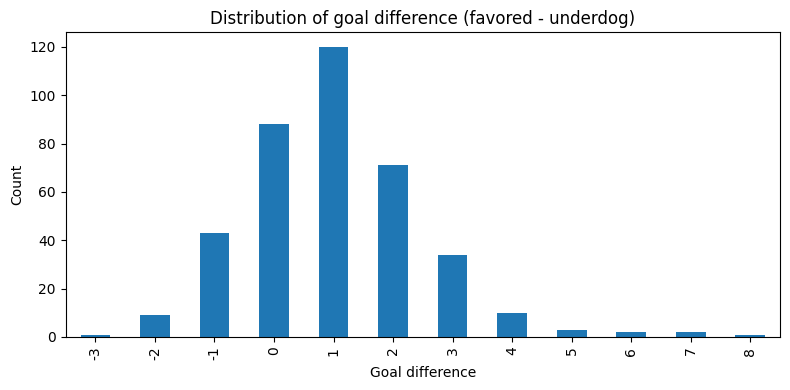

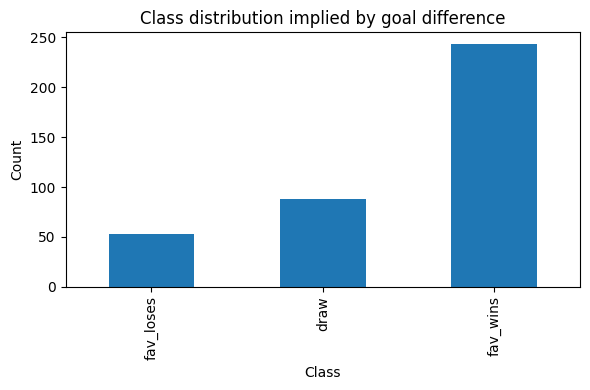

In [24]:
plt.figure(figsize=(8, 4))
df_reg["goal_diff"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of goal difference (favored - underdog)")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("image/output2/distribution_goal_diff.png")
plt.show()

plt.figure(figsize=(6, 4))
df_reg["true_class"].value_counts().reindex(["fav_loses", "draw", "fav_wins"]).plot(
    kind="bar"
)
plt.title("Class distribution implied by goal difference")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("image/output2/class_distribution_implied_goal_diff.png")
plt.show()

## 10. Save objects for next step

In [25]:
regression_objects = {
    "df_reg": df_reg,
    "X": X,
    "y": y,
    "years": years,
    "X_train": X_train,
    "y_train": y_train,
    "year_train": year_train,
    "X_holdout": X_holdout,
    "y_holdout": y_holdout,
    "year_holdout": year_holdout,
    "df_train": df_train,
    "df_holdout": df_holdout,
    "home_score_col": home_score_col,
    "away_score_col": away_score_col,
}

print("Part 2 completed successfully.")

Part 2 completed successfully.


## Interpretation

The overall target construction looks sensible:

- goal difference is centered around small positive values
- draws are common (`88 / 384`)
- favored wins dominate (`243 / 384`)
- the train/holdout split is exactly what we wanted: `256 / 128`

The histograms also look reasonable for soccer:

- most matches are between -1 and +2
- 0 and 1 are the two biggest masses
- large margins are rare, as expected

The 0.9453 agreement is almost certainly because of **penalty-shootout matches**. Because in every mismatch we showed here, the score difference is `0`, but Mingjie’s `y3` is sometimes win/loss rather than draw. That happens when:

- the match score is tied after regular time / extra time
- but the official advancement outcome is decided by penalties

So our regression target:

$$\text{goal\_diff} = \text{fav goals} - \text{und goals}$$

cannot represent shootout winners, because penalties do not show up as a normal score margin.

## Regression Design

Therefore, for the **score-difference regression experiment**, I decide to **drop penalty shootout matches from the regression dataset** because:

- our target is score difference
- shootout-decided matches have goal_diff = 0
- but their final outcome is not a draw in Mingjie’s label definition
- leaving them in will create a conceptual mismatch between target and label mapping

This is the statistically clean choice.

If we keep them in, then one of the following must happen:

1. predict `goal_diff = 0` and call it draw
    - then this disagrees with Mingjie’s label on shootout matches
2. predict `goal_diff = 0` but somehow map it to win/loss
    - impossible from score difference alone

So for a clean regression analysis, penalty shootouts should be excluded.

# Part 2.5: Filter out Penalty-shootout Matches

This part removes penalty-shootout matches for regression. 

## 1. Detect penalty-shootout column in matches

In [26]:
candidate_pso_cols = [
    "penalty_shootout",
    "penalties",
    "decided_by_penalties",
    "penalty_shoot_out",
]

pso_col = next((c for c in candidate_pso_cols if c in matches.columns), None)

print("Detected penalty-shootout column:", pso_col)

if pso_col is None:
    print("\nCould not auto-detect a penalty-shootout column in matches.")
    print("Columns in matches containing 'pen' or 'shoot':")
    possible = [
        c for c in matches.columns if ("pen" in c.lower()) or ("shoot" in c.lower())
    ]
    print(possible)
    raise ValueError("Please inspect the printed columns and manually set pso_col.")

Detected penalty-shootout column: penalty_shootout


## 2. Merge penalty-shootout flag into df_reg

In [27]:
pso_df = matches[["match_id", pso_col]].copy()
df_reg2 = df_reg.merge(pso_df, on="match_id", how="left", suffixes=("", "_pso"))

print("Penalty-shootout flag distribution:")
print(df_reg2[pso_col].value_counts(dropna=False))

Penalty-shootout flag distribution:
penalty_shootout
0    363
1     21
Name: count, dtype: int64


## 3. Remove shootout matches

In [28]:
# Treat 1/True as shootout matches. Everything else stays.
keep_mask = ~(df_reg2[pso_col].fillna(0).astype(int) == 1)
df_reg_clean = df_reg2.loc[keep_mask].reset_index(drop=True)

print("Shapes:")
print("Before removing shootouts:", df_reg2.shape)
print("After removing shootouts :", df_reg_clean.shape)
print("Dropped rows:", len(df_reg2) - len(df_reg_clean))

Shapes:
Before removing shootouts: (384, 194)
After removing shootouts : (363, 194)
Dropped rows: 21


## 4. Rebuild train/holdout split

In [29]:
X_clean = df_reg_clean[fav_num_cols].copy()
y_clean = df_reg_clean["goal_diff"].copy()
years_clean = df_reg_clean["year"].copy()

train_mask_clean = years_clean < 2018
holdout_mask_clean = years_clean.isin([2018, 2022])

X_train = X_clean.loc[train_mask_clean].reset_index(drop=True)
y_train = y_clean.loc[train_mask_clean].reset_index(drop=True)
year_train = years_clean.loc[train_mask_clean].reset_index(drop=True)

X_holdout = X_clean.loc[holdout_mask_clean].reset_index(drop=True)
y_holdout = y_clean.loc[holdout_mask_clean].reset_index(drop=True)
year_holdout = years_clean.loc[holdout_mask_clean].reset_index(drop=True)

df_train = df_reg_clean.loc[train_mask_clean].reset_index(drop=True)
df_holdout = df_reg_clean.loc[holdout_mask_clean].reset_index(drop=True)

print("Clean split summary:")
print("Train size:", len(X_train))
print("Holdout size:", len(X_holdout))

print("\nTrain goal_diff distribution:")
print(y_train.value_counts().sort_index())

print("\nHoldout goal_diff distribution:")
print(y_holdout.value_counts().sort_index())

Clean split summary:
Train size: 244
Holdout size: 119

Train goal_diff distribution:
goal_diff
-3     1
-2     7
-1    25
 0    48
 1    83
 2    45
 3    22
 4     9
 6     2
 7     1
 8     1
Name: count, dtype: int64

Holdout goal_diff distribution:
goal_diff
-2     2
-1    18
 0    19
 1    37
 2    26
 3    12
 4     1
 5     3
 7     1
Name: count, dtype: int64


## 5. Check class agreement again

In [30]:
def diff_to_y3(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


df_reg_clean["y3_from_goal_diff"] = df_reg_clean["goal_diff"].apply(diff_to_y3)
agreement_clean = (df_reg_clean["y3_from_goal_diff"] == df_reg_clean["y3"]).mean()

print("Agreement after removing shootouts:", round(agreement_clean, 4))

Agreement after removing shootouts: 1.0


## 6. Missingness check again

In [31]:
missing_rate_clean = X_train.isna().mean().sort_values(ascending=False)

print("Top 20 missing-rate features after shootout filtering:")
print(missing_rate_clean.head(20))

Top 20 missing-rate features after shootout filtering:
und_hist_pso_win_rate_shrunk                0.713115
feat_away_mgr_hist_win_rate_shrunk          0.700820
feat_home_mgr_hist_win_rate_shrunk          0.696721
fav_hist_pso_win_rate_shrunk                0.360656
fav_rest_days_since_prev_match              0.262295
und_rest_days_since_prev_match              0.262295
feat_rest_days_diff                         0.262295
feat_away_hist_win_rate_vs_home_conf        0.196721
feat_hist_goal_diff_per_match_diff          0.172131
und_squad_squad_jaccard_vs_prev_wc          0.143443
und_hist_goal_diff_per_match                0.143443
und_hist_frac_tournaments_reached_ko        0.143443
und_hist_et_rate                            0.143443
und_squad_squad_overlap_count_vs_prev_wc    0.143443
feat_home_hist_win_rate_vs_away_conf        0.114754
fav_hist_goal_diff_per_match                0.032787
fav_hist_frac_tournaments_reached_ko        0.032787
fav_squad_squad_overlap_count_vs_prev_wc    

## 7. Save cleaned objects

In [32]:
regression_objects_clean = {
    "df_reg_clean": df_reg_clean,
    "X_train": X_train,
    "y_train": y_train,
    "year_train": year_train,
    "X_holdout": X_holdout,
    "y_holdout": y_holdout,
    "year_holdout": year_holdout,
    "df_train": df_train,
    "df_holdout": df_holdout,
    "pso_col": pso_col,
}

print("Part 2.5 completed successfully.")

Part 2.5 completed successfully.


This is now clean.

The important part is:

- `21` penalty-shootout matches removed
- agreement is now **1.0**
- training set is `244` matches
- holdout is `119` matches

That is exactly what we want for a coherent score-difference regression setup.

# Part 3: First Baseline Regression Models

For this step, let’s keep it simple and disciplined.

We will run:

1. **DummyRegressor** as a naive benchmark
2. **Ridge regression** as the first real model

We will evaluate with:

- **LOTO CV by World Cup year** on training set
- **MAE**
- **RMSE**
- final **holdout MAE / RMSE**

We are **not** doing thresholding yet.
This step is only about continuous regression quality.

## 1. Pull cleaned objects

In [33]:
if "regression_objects_clean" not in globals():
    raise ValueError("regression_objects_clean not found. Please run Part 2.5 first.")

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

print("Train shape:", X_train.shape, y_train.shape)
print("Holdout shape:", X_holdout.shape, y_holdout.shape)
print("Training years:", sorted(pd.Series(year_train).unique()))

Train shape: (244, 97) (244,)
Holdout shape: (119, 97) (119,)
Training years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]


## 2. Define CV


In [34]:
logo = LeaveOneGroupOut()

## 3. Dummy benchmark

In [35]:
dummy_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyRegressor(strategy="mean")),
    ]
)

dummy_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    dummy_model = clone(dummy_pipe)
    dummy_model.fit(X_tr, y_tr)
    pred_va = dummy_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    dummy_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
        }
    )

dummy_cv = pd.DataFrame(dummy_cv_rows)

print("DummyRegressor LOTO CV results:")
print(dummy_cv)

print("\nDummyRegressor mean CV metrics:")
print(dummy_cv[["mae", "rmse"]].mean())

# Fit dummy on full train and evaluate holdout
dummy_full = clone(dummy_pipe)
dummy_full.fit(X_train, y_train)
dummy_holdout_pred = dummy_full.predict(X_holdout)

dummy_holdout_mae = mean_absolute_error(y_holdout, dummy_holdout_pred)
dummy_holdout_rmse = mean_squared_error(y_holdout, dummy_holdout_pred) ** 0.5

print("\nDummyRegressor holdout metrics:")
print(
    {
        "holdout_mae": dummy_holdout_mae,
        "holdout_rmse": dummy_holdout_rmse,
        "holdout_pred_mean": float(np.mean(dummy_holdout_pred)),
    }
)

DummyRegressor LOTO CV results:
   fold val_year       mae      rmse  pred_mean
0     1   [2002]  1.271889  1.702125   1.148352
1     2   [2006]  1.052536  1.444452   0.994565
2     3   [2010]  0.953917  1.419267   1.071429
3     4   [2014]  1.132971  1.583555   1.048913

DummyRegressor mean CV metrics:
mae     1.102828
rmse    1.537350
dtype: float64

DummyRegressor holdout metrics:
{'holdout_mae': 1.127428020388483, 'holdout_rmse': 1.520725763806749, 'holdout_pred_mean': 1.0655737704918034}


## 4. Ridge model + alpha tuning

In [36]:
ridge_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge()),
    ]
)

alpha_grid = {"model__alpha": [0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0]}

ridge_search = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=alpha_grid,
    scoring="neg_mean_absolute_error",
    cv=logo.split(X_train, y_train, groups=year_train),
    n_jobs=-1,
    refit=True,
)

ridge_search.fit(X_train, y_train)

print("Best Ridge alpha:")
print(ridge_search.best_params_)
print("Best Ridge CV MAE:", -ridge_search.best_score_)

best_ridge = ridge_search.best_estimator_

Best Ridge alpha:
{'model__alpha': 100.0}
Best Ridge CV MAE: 1.1608286080386938


## 5. Manual fold-by-fold Ridge CV report

In [37]:
ridge_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    fold_model = clone(best_ridge)
    fold_model.fit(X_tr, y_tr)
    pred_va = fold_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    ridge_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
            "pred_std": float(np.std(pred_va)),
        }
    )

ridge_cv = pd.DataFrame(ridge_cv_rows)

print("Ridge LOTO CV results:")
print(ridge_cv)

print("\nRidge mean CV metrics:")
print(ridge_cv[["mae", "rmse"]].mean())

Ridge LOTO CV results:
   fold val_year       mae      rmse  pred_mean  pred_std
0     1   [2002]  1.196391  1.622967   0.944931  0.478804
1     2   [2006]  1.123812  1.516478   0.850745  0.626943
2     3   [2010]  1.037697  1.468814   1.113786  0.701210
3     4   [2014]  1.285416  1.668017   1.175221  0.672237

Ridge mean CV metrics:
mae     1.160829
rmse    1.569069
dtype: float64


## 6. Fit best Ridge on full train and evaluate holdout

In [38]:
best_ridge.fit(X_train, y_train)
ridge_holdout_pred = best_ridge.predict(X_holdout)

ridge_holdout_mae = mean_absolute_error(y_holdout, ridge_holdout_pred)
ridge_holdout_rmse = mean_squared_error(y_holdout, ridge_holdout_pred) ** 0.5

print("Ridge holdout metrics:")
print(
    {
        "holdout_mae": ridge_holdout_mae,
        "holdout_rmse": ridge_holdout_rmse,
        "pred_mean": float(np.mean(ridge_holdout_pred)),
        "pred_std": float(np.std(ridge_holdout_pred)),
        "true_mean": float(np.mean(y_holdout)),
        "true_std": float(np.std(y_holdout)),
    }
)

Ridge holdout metrics:
{'holdout_mae': 1.153497220906074, 'holdout_rmse': 1.4837031818155397, 'pred_mean': 0.8978357146947472, 'pred_std': 0.5476522490501561, 'true_mean': 1.084033613445378, 'true_std': 1.52061371916202}


## 7. Simple holdout diagnostics

Holdout prediction preview:
    year  y_true  y_pred_dummy  y_pred_ridge
0   2018       5      1.065574      1.045316
1   2018       1      1.065574      0.748190
2   2018       1      1.065574      0.720206
3   2018       0      1.065574      0.503243
4   2018       1      1.065574      2.101610
5   2018       0      1.065574      0.944551
6   2018       1      1.065574      0.538731
7   2018       2      1.065574      0.784224
8   2018       1      1.065574      1.320244
9   2018      -1      1.065574      0.820133
10  2018       0      1.065574      1.190154
11  2018       1      1.065574      0.592502
12  2018       3      1.065574      1.469550
13  2018       1      1.065574      1.183791
14  2018      -1      1.065574      0.889953


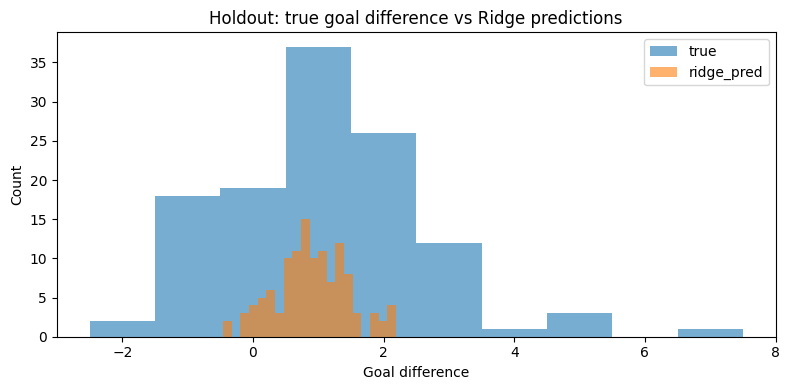

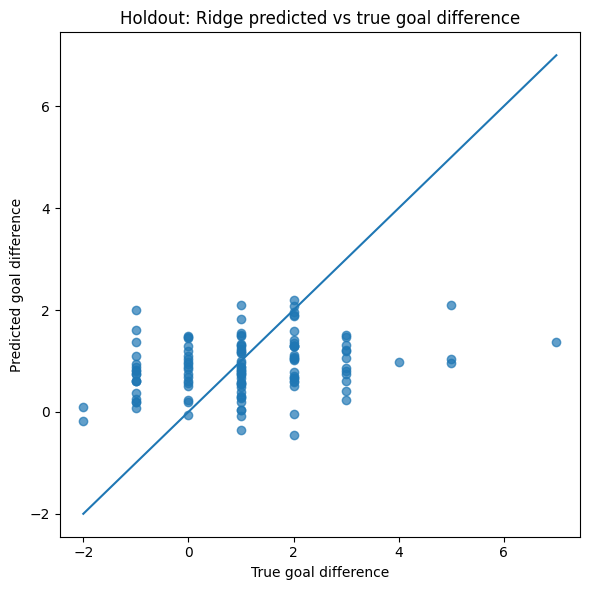

In [39]:
holdout_results = pd.DataFrame(
    {
        "year": year_holdout,
        "y_true": y_holdout,
        "y_pred_dummy": dummy_holdout_pred,
        "y_pred_ridge": ridge_holdout_pred,
    }
)

print("Holdout prediction preview:")
print(holdout_results.head(15))

# Plot 1: prediction distribution
plt.figure(figsize=(8, 4))
plt.hist(
    y_holdout,
    bins=np.arange(y_holdout.min() - 0.5, y_holdout.max() + 1.5, 1),
    alpha=0.6,
    label="true",
)
plt.hist(ridge_holdout_pred, bins=20, alpha=0.6, label="ridge_pred")
plt.title("Holdout: true goal difference vs Ridge predictions")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("image/output3/hist_holdout_true_goal_diff_vs_ridge_pred.png")
plt.show()

# Plot 2: scatter of true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_holdout, ridge_holdout_pred, alpha=0.7)
plt.plot(
    [
        min(y_holdout.min(), ridge_holdout_pred.min()),
        max(y_holdout.max(), ridge_holdout_pred.max()),
    ],
    [
        min(y_holdout.min(), ridge_holdout_pred.min()),
        max(y_holdout.max(), ridge_holdout_pred.max()),
    ],
)
plt.title("Holdout: Ridge predicted vs true goal difference")
plt.xlabel("True goal difference")
plt.ylabel("Predicted goal difference")
plt.tight_layout()
plt.savefig("image/output3/scatter_holdout_ridge_pred_vs_true_goal_diff.png")
plt.show()

## 8. Save for next step

In [40]:
part3_objects = {
    "dummy_cv": dummy_cv,
    "ridge_cv": ridge_cv,
    "best_ridge": best_ridge,
    "ridge_search": ridge_search,
    "holdout_results": holdout_results,
    "ridge_holdout_pred": ridge_holdout_pred,
    "dummy_holdout_pred": dummy_holdout_pred,
}
print("Part 3 completed successfully.")

Part 3 completed successfully.


## Interpretation of Part 3

### MAE

Ridge is **not convincing as a strong model** here.

The main signals are:

* **Dummy CV MAE:** `1.103`
* **Ridge CV MAE:** `1.161`

So on cross-validation, Ridge is actually **worse than predicting the training mean**.

On holdout:

* **Dummy holdout MAE:** `1.127`
* **Ridge holdout MAE:** `1.153`

Again, Ridge is **worse on MAE**.

### RMSE

Ridge does get a slightly better holdout RMSE:

* Dummy RMSE: `1.521`
* Ridge RMSE: `1.484`

But that is not enough to call it better overall, especially since MAE is the cleaner metric here.

### What the plots say

The plots confirm what the numbers suggest:

* Ridge predictions are **compressed into a narrow band**
* predicted values are mostly around `0.5` to `1.5`
* it does **not capture extremes well**
* it has trouble producing strong negative margins or large positive margins

That is also why the best alpha went all the way to `100.0`: the model wants  **heavy shrinkage** , which usually means the linear signal is weak relative to noise.

## Conclusion

> Ridge is a useful baseline, but it is not learning a strong enough continuous signal from these features.

# Part 4: Tune the Draw Threshold for Ridge

Even though Ridge is not a strong regressor, it is still worth checking whether its continuous predictions can be converted into decent 3-class predictions.

We will now:

1. generate **out-of-fold Ridge predictions** on the training set
2. search over a **symmetric threshold** tt**t**
3. pick the threshold that maximizes **macro F1**
4. evaluate that threshold on the **holdout**

This will tell us whether regression can still be useful as a classifier after thresholding.

## 1. Pull objects

In [41]:
if "part3_objects" not in globals():
    raise ValueError("part3_objects not found. Please run Part 3 first.")

best_ridge = part3_objects["best_ridge"]

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

logo = LeaveOneGroupOut()

## 2. Helper function

In [42]:
def diff_to_y3_from_true(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


def pred_to_y3(pred, threshold):
    # symmetric threshold
    # pred > t => favored win
    # pred < -t => favored loss
    # otherwise draw
    pred = np.asarray(pred)
    out = np.where(pred > threshold, 2, np.where(pred < -threshold, 0, 1))
    return out


# True 3-class labels implied by goal_diff
y_train_cls = np.array([diff_to_y3_from_true(v) for v in y_train])
y_holdout_cls = np.array([diff_to_y3_from_true(v) for v in y_holdout])

## 3. Out-of-fold Ridge predictions on train

In [43]:
oof_pred = np.empty(len(X_train), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr = y_train.iloc[tr_idx]

    fold_model = clone(best_ridge)
    fold_model.fit(X_tr, y_tr)
    oof_pred[va_idx] = fold_model.predict(X_va)

print("OOF prediction summary:")
print(pd.Series(oof_pred).describe())

OOF prediction summary:
count    244.000000
mean       1.021305
std        0.639750
min       -0.696381
25%        0.585740
50%        1.026074
75%        1.428045
max        2.777342
dtype: float64


## 4. Threshold search on OOF predictions

In [44]:
threshold_grid = np.round(np.arange(0.05, 1.55, 0.05), 2)

rows = []
for t in threshold_grid:
    pred_cls = pred_to_y3(oof_pred, threshold=t)

    acc = accuracy_score(y_train_cls, pred_cls)
    macro_f1 = f1_score(y_train_cls, pred_cls, average="macro")
    macro_f1_weighted = f1_score(y_train_cls, pred_cls, average="weighted")

    draw_rate = np.mean(pred_cls == 1)
    fav_win_rate = np.mean(pred_cls == 2)
    fav_loss_rate = np.mean(pred_cls == 0)

    rows.append(
        {
            "threshold": t,
            "accuracy": acc,
            "macro_f1": macro_f1,
            "weighted_f1": macro_f1_weighted,
            "pred_draw_rate": draw_rate,
            "pred_fav_win_rate": fav_win_rate,
            "pred_fav_loss_rate": fav_loss_rate,
        }
    )

threshold_results = pd.DataFrame(rows)
threshold_ranked = threshold_results.sort_values(
    ["macro_f1", "accuracy"], ascending=[False, False]
).reset_index(drop=True)

best_threshold = threshold_ranked.loc[0, "threshold"]
print("Selected threshold:", best_threshold)
print("\nTop 15 threshold candidates by OOF macro F1:")
print(threshold_ranked.head(15))

Selected threshold: 0.5

Top 15 threshold candidates by OOF macro F1:
    threshold  accuracy  macro_f1  weighted_f1  pred_draw_rate  \
0        0.50  0.627049  0.374276     0.580729        0.192623   
1        0.65  0.598361  0.366168     0.568877        0.295082   
2        0.60  0.606557  0.364843     0.569831        0.258197   
3        0.55  0.618852  0.364543     0.575002        0.225410   
4        0.45  0.622951  0.362945     0.572631        0.176230   
5        0.70  0.586066  0.361421     0.561033        0.323770   
6        0.75  0.577869  0.359712     0.556653        0.344262   
7        0.40  0.614754  0.354096     0.561728        0.151639   
8        0.35  0.627049  0.353551     0.564757        0.122951   
9        0.80  0.557377  0.351323     0.542493        0.377049   
10       0.25  0.631148  0.348326     0.563005        0.102459   
11       0.85  0.540984  0.347268     0.531475        0.413934   
12       0.30  0.627049  0.346781     0.560374        0.110656   
13    

## 5. Refit Ridge on full train and predict holdout

In [45]:
ridge_final = clone(best_ridge)
ridge_final.fit(X_train, y_train)
holdout_pred_cont = ridge_final.predict(X_holdout)

holdout_pred_cls = pred_to_y3(holdout_pred_cont, threshold=best_threshold)

## 6. Holdout classification metrics

In [46]:
holdout_acc = accuracy_score(y_holdout_cls, holdout_pred_cls)
holdout_macro_f1 = f1_score(y_holdout_cls, holdout_pred_cls, average="macro")
holdout_weighted_f1 = f1_score(y_holdout_cls, holdout_pred_cls, average="weighted")
cm = confusion_matrix(y_holdout_cls, holdout_pred_cls, labels=[0, 1, 2])

print("Holdout classification metrics from Ridge + threshold:")
print(
    {
        "threshold": best_threshold,
        "accuracy": holdout_acc,
        "macro_f1": holdout_macro_f1,
        "weighted_f1": holdout_weighted_f1,
    }
)

print(
    "\nHoldout confusion matrix (rows=true, cols=pred) with label order [0=fav_loss, 1=draw, 2=fav_win]:"
)
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_holdout_cls,
        holdout_pred_cls,
        labels=[0, 1, 2],
        target_names=["fav_loses", "draw", "fav_wins"],
        digits=4,
    )
)

Holdout classification metrics from Ridge + threshold:
{'threshold': np.float64(0.5), 'accuracy': 0.5798319327731093, 'macro_f1': 0.2979401993355482, 'weighted_f1': 0.5293615120466793}

Holdout confusion matrix (rows=true, cols=pred) with label order [0=fav_loss, 1=draw, 2=fav_win]:
[[ 0  7 13]
 [ 0  3 16]
 [ 0 14 66]]

Classification report:
              precision    recall  f1-score   support

   fav_loses     0.0000    0.0000    0.0000        20
        draw     0.1250    0.1579    0.1395        19
    fav_wins     0.6947    0.8250    0.7543        80

    accuracy                         0.5798       119
   macro avg     0.2732    0.3276    0.2979       119
weighted avg     0.4870    0.5798    0.5294       119



C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## 7. Compare predicted class distribution vs true

In [47]:
dist_compare = (
    pd.DataFrame(
        {
            "true_count": pd.Series(y_holdout_cls).value_counts().sort_index(),
            "pred_count": pd.Series(holdout_pred_cls).value_counts().sort_index(),
        }
    )
    .fillna(0)
    .astype(int)
)

dist_compare.index = ["fav_loses", "draw", "fav_wins"]

print("\nHoldout class distribution comparison:")
print(dist_compare)


Holdout class distribution comparison:
           true_count  pred_count
fav_loses          20           0
draw               19          24
fav_wins           80          95


## 8. Plot threshold curve

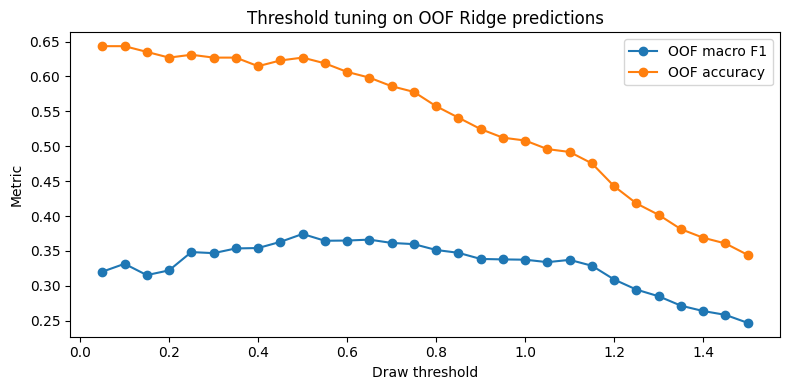

In [48]:
plot_df = threshold_results.sort_values("threshold").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["threshold"], plot_df["macro_f1"], marker="o", label="OOF macro F1")
plt.plot(plot_df["threshold"], plot_df["accuracy"], marker="o", label="OOF accuracy")
plt.title("Threshold tuning on OOF Ridge predictions")
plt.xlabel("Draw threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.savefig("image/output4/threshold_tuning_on_oof_ridge_predictions.png")
plt.show()

## 9. Plot holdout continuous predictions with threshold bands

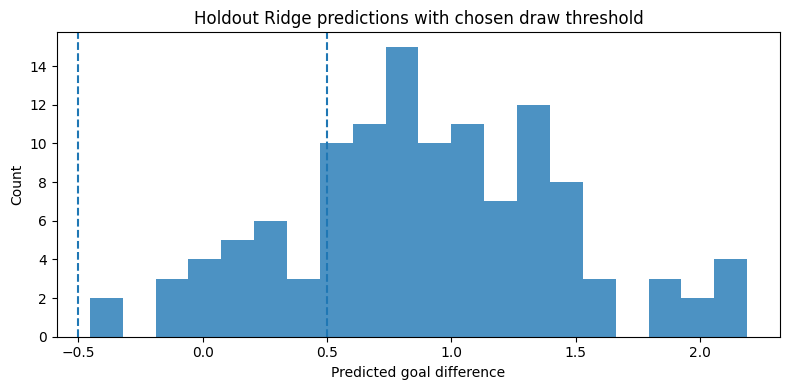

In [49]:
plt.figure(figsize=(8, 4))
plt.hist(holdout_pred_cont, bins=20, alpha=0.8)
plt.axvline(best_threshold, linestyle="--")
plt.axvline(-best_threshold, linestyle="--")
plt.title("Holdout Ridge predictions with chosen draw threshold")
plt.xlabel("Predicted goal difference")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("image/output4/holdout_ridge_predictions_with_chosen_draw_threshold.png")
plt.show()

## 10. Save objects

In [50]:
part4_objects = {
    "threshold_results": threshold_results,
    "best_threshold": best_threshold,
    "holdout_pred_cont": holdout_pred_cont,
    "holdout_pred_cls": holdout_pred_cls,
    "y_holdout_cls": y_holdout_cls,
    "confusion_matrix": cm,
    "holdout_accuracy": holdout_acc,
    "holdout_macro_f1": holdout_macro_f1,
    "holdout_weighted_f1": holdout_weighted_f1,
}

print("\nPart 4 completed successfully.")


Part 4 completed successfully.


## Interpretation

This is a strong result, even though it is negative. The regression-to-classification route with **Ridge** does **not perform well enough**.

The core problems are:

* selected threshold: **0.5**
* holdout accuracy: **0.580**
* holdout macro F1: **0.298**
* predicted **zero favored losses**

That last point is the biggest issue.

Our confusion matrix:

$$
\begin{bmatrix}
0 & 7 & 13 \\
0 & 3 & 16 \\
0 & 14 & 66
\end{bmatrix}
$$

shows that Ridge is basically doing this:

* mostly predicts **favored win**
* sometimes predicts **draw**
* almost **never predicts favored loss**

So even though the continuous regression target made conceptual sense, this particular linear regression model does **not** generate a useful enough spread of predictions to recover the 3-class problem well.

### Plots

The threshold plot makes sense visually:

* macro F1 peaks around `0.5`
* accuracy declines as the draw band widens too much
* that is consistent with our selected threshold

## Conclusion

We now have a clean story for the report:

1. score-difference regression is a valid alternative framing
2. penalty shootout matches must be removed for coherence
3. a linear regressor like Ridge is too compressed and fails especially on favored-loss cases
4. therefore, if regression is to be useful, it likely needs a **nonlinear model**

## Next Steps

Based on the results, I suggest the following change to our original pipeline: 

- keep Ridge as our linear baseline
- skip Lasso unless we specifically want another linear benchmark
- then do Random Forest and XGBoost

Why:

- Ridge already shows the linear-regression route is weak
- Lasso is still linear, so it is unlikely to fundamentally change the story
- Random Forest and XGBoost are more likely to add real value

That gives us a nice progression:

- Ridge — linear baseline
- Random Forest — nonlinear bagging model
- XGBoost — nonlinear boosting model

That is also easier to explain in the report, because we move from:

- linear
- to nonlinear ensemble
- to stronger boosted ensemble

Random Forest is a good intermediate test because:

- it captures nonlinearities
- it can model interactions automatically
- it is usually more stable and easier to tune than XGBoost
- if even Random Forest fails, then we know the issue is deeper than just linearity

If Random Forest improves meaningfully over Ridge, then XGBoost becomes a natural final attempt to see whether boosting improves further.

# Part 5 — Random Forest Regressor

This part will:

1. tune a Random Forest with LOTO CV on the training set
2. optimize for **MAE**
3. report fold-by-fold CV results
4. evaluate on the 2018+2022 holdout
5. compare directly against Ridge

## 1. Pull cleaned data

In [51]:
if "regression_objects_clean" not in globals():
    raise ValueError("regression_objects_clean not found. Please run Part 2.5 first.")
if "part3_objects" not in globals():
    raise ValueError("part3_objects not found. Please run Part 3 first.")

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

logo = LeaveOneGroupOut()

print("Train shape:", X_train.shape, y_train.shape)
print("Holdout shape:", X_holdout.shape, y_holdout.shape)
print("Training years:", sorted(pd.Series(year_train).unique()))

Train shape: (244, 97) (244,)
Holdout shape: (119, 97) (119,)
Training years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]


## 2. Define pipeline

In [52]:
rf_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

## 3. Search grid

Keep this moderate because the dataset is small

In [53]:
param_grid = {
    "model__n_estimators": [200, 500],
    "model__max_depth": [3, 5, 8, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 0.8],
}

## 4. Grid search with LOTO CV

In [54]:
rf_search = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=logo.split(X_train, y_train, groups=year_train),
    n_jobs=-1,
    verbose=1,
    refit=True,
)

rf_search.fit(X_train, y_train)

print("Best RF params:")
print(rf_search.best_params_)
print("Best RF CV MAE:", -rf_search.best_score_)

best_rf = rf_search.best_estimator_

Fitting 4 folds for each of 216 candidates, totalling 864 fits
Best RF params:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best RF CV MAE: 1.1017016129032255


## 5. Manual fold-by-fold CV report

In [55]:
rf_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    fold_model = clone(best_rf)
    fold_model.fit(X_tr, y_tr)
    pred_va = fold_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    rf_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
            "pred_std": float(np.std(pred_va)),
            "pred_min": float(np.min(pred_va)),
            "pred_max": float(np.max(pred_va)),
        }
    )

rf_cv = pd.DataFrame(rf_cv_rows)

print("RandomForestRegressor LOTO CV results:")
print(rf_cv)

print("\nRandomForestRegressor mean CV metrics:")
print(rf_cv[["mae", "rmse"]].mean())

RandomForestRegressor LOTO CV results:
   fold val_year       mae      rmse  pred_mean  pred_std  pred_min  pred_max
0     1   [2002]  1.223306  1.654193   1.148306  0.313419     0.140     1.875
1     2   [2006]  1.075667  1.459102   0.861833  0.372008     0.015     1.535
2     3   [2010]  0.980000  1.400804   1.130161  0.419279     0.150     2.160
3     4   [2014]  1.127833  1.492295   1.101667  0.368024     0.270     2.280

RandomForestRegressor mean CV metrics:
mae     1.101702
rmse    1.501599
dtype: float64


## 6. Fit on full train and evaluate holdout

In [56]:
best_rf.fit(X_train, y_train)
rf_holdout_pred = best_rf.predict(X_holdout)

rf_holdout_mae = mean_absolute_error(y_holdout, rf_holdout_pred)
rf_holdout_rmse = mean_squared_error(y_holdout, rf_holdout_pred) ** 0.5

print("RandomForestRegressor holdout metrics:")
print(
    {
        "holdout_mae": rf_holdout_mae,
        "holdout_rmse": rf_holdout_rmse,
        "pred_mean": float(np.mean(rf_holdout_pred)),
        "pred_std": float(np.std(rf_holdout_pred)),
        "pred_min": float(np.min(rf_holdout_pred)),
        "pred_max": float(np.max(rf_holdout_pred)),
        "true_mean": float(np.mean(y_holdout)),
        "true_std": float(np.std(y_holdout)),
    }
)

RandomForestRegressor holdout metrics:
{'holdout_mae': 1.139747899159664, 'holdout_rmse': 1.470675543626754, 'pred_mean': 1.1207563025210086, 'pred_std': 0.3820360308227914, 'pred_min': 0.25, 'pred_max': 2.145, 'true_mean': 1.084033613445378, 'true_std': 1.52061371916202}


## 7. Compare with Ridge

In [57]:
ridge_cv_mean = part3_objects["ridge_cv"][["mae", "rmse"]].mean()
ridge_holdout_pred = part3_objects["ridge_holdout_pred"]

ridge_holdout_mae = mean_absolute_error(y_holdout, ridge_holdout_pred)
ridge_holdout_rmse = mean_squared_error(y_holdout, ridge_holdout_pred) ** 0.5

comparison = pd.DataFrame(
    {
        "model": ["Ridge", "RandomForestRegressor"],
        "cv_mae": [ridge_cv_mean["mae"], rf_cv["mae"].mean()],
        "cv_rmse": [ridge_cv_mean["rmse"], rf_cv["rmse"].mean()],
        "holdout_mae": [ridge_holdout_mae, rf_holdout_mae],
        "holdout_rmse": [ridge_holdout_rmse, rf_holdout_rmse],
    }
)

print("Model comparison:")
print(comparison)

Model comparison:
                   model    cv_mae   cv_rmse  holdout_mae  holdout_rmse
0                  Ridge  1.160829  1.569069     1.153497      1.483703
1  RandomForestRegressor  1.101702  1.501599     1.139748      1.470676


## 8. Holdout diagnostics

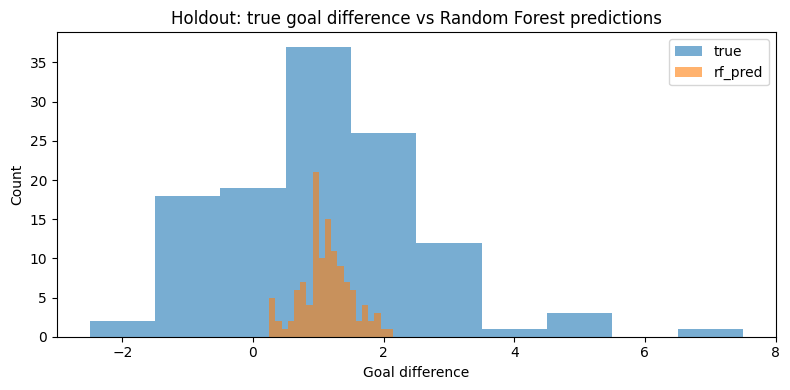

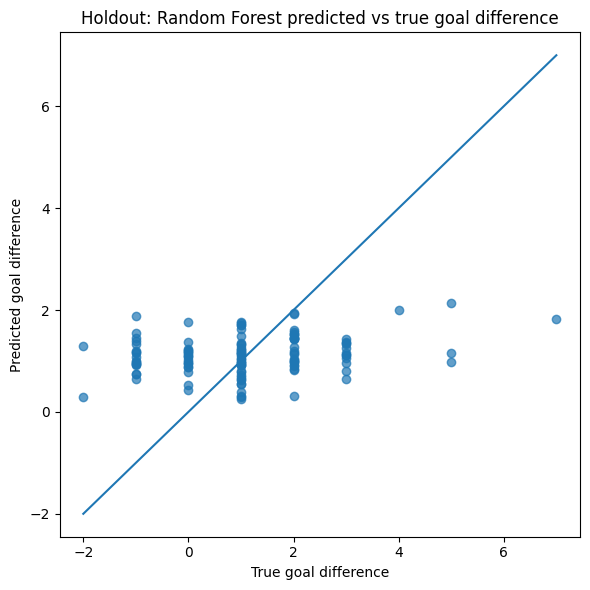

In [60]:
plt.figure(figsize=(8, 4))
plt.hist(
    y_holdout,
    bins=np.arange(y_holdout.min() - 0.5, y_holdout.max() + 1.5, 1),
    alpha=0.6,
    label="true",
)
plt.hist(rf_holdout_pred, bins=20, alpha=0.6, label="rf_pred")
plt.title("Holdout: true goal difference vs Random Forest predictions")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("image/output5/holdout_rf_hist.png")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_holdout, rf_holdout_pred, alpha=0.7)
mn = min(y_holdout.min(), rf_holdout_pred.min())
mx = max(y_holdout.max(), rf_holdout_pred.max())
plt.plot([mn, mx], [mn, mx])
plt.title("Holdout: Random Forest predicted vs true goal difference")
plt.xlabel("True goal difference")
plt.ylabel("Predicted goal difference")
plt.tight_layout()
plt.savefig("image/output5/holdout_rf_scatter.png")
plt.show()

## 9. Save objects for next step

In [61]:
part5_objects = {
    "rf_search": rf_search,
    "best_rf": best_rf,
    "rf_cv": rf_cv,
    "rf_holdout_pred": rf_holdout_pred,
    "comparison": comparison,
}

print("Part 5 completed successfully.")

Part 5 completed successfully.


## Interpretation

Random Forest is **slightly better than Ridge**, but only marginally.

### Compared with Ridge

* **CV MAE:** `1.1017` vs Ridge `1.1608`
* **CV RMSE:** `1.5016` vs Ridge `1.5691`
* **Holdout MAE:** `1.1397` vs Ridge `1.1535`
* **Holdout RMSE:** `1.4707` vs Ridge `1.4837`

So Random Forest does improve on Ridge across all four metrics. But the more important comparison is against Dummy. From Part 3, Dummy had:

* **CV MAE:** `1.1028`
* **Holdout MAE:** `1.1274`

So Random Forest is essentially **tied with Dummy on CVMAE** and still **worse than Dummy on holdout MAE**. That means the gain over Ridge is real, but the gain over a naive baseline is still not convincing.

### About Plots

The Random Forest predictions are still very compressed:

* `pred_min = 0.25`
* `pred_max = 2.145`
* `pred_std = 0.382`

That is actually **more compressed than Ridge** on holdout.

So even though the MAE/RMSE improved a bit, the model is still mostly predicting modest positive margins for the favored team. That means it is still unlikely to do well on:

* favored losses
* stronger draws
* large-margin matches

In other words, random forest improves continuous error a little, but it still does not produce the kind of prediction spread we would want for a strong 3-class mapping.

### Conclusion

1. **Ridge** underfits badly
2. **Random Forest** improves over Ridge a bit
3. but even Random Forest does **not clearly beat a naive baseline**
4. and its prediction range is still too narrow

So I would **not** spend time threshold-tuning Random Forest.

# Part 6 — XGBoost Regressor

This part tests whether boosted trees beat Ridge and RF.

## 1. Import XGBoost

In [62]:
try:
    from xgboost import XGBRegressor
except ImportError:
    raise ImportError("xgboost is not installed in this environment.")

## 2. Pull cleaned data

In [63]:
if "regression_objects_clean" not in globals():
    raise ValueError("regression_objects_clean not found. Please run Part 2.5 first.")
if "part3_objects" not in globals():
    raise ValueError("part3_objects not found. Please run Part 3 first.")
if "part5_objects" not in globals():
    raise ValueError("part5_objects not found. Please run Part 5 first.")

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

logo = LeaveOneGroupOut()

print("Train shape:", X_train.shape, y_train.shape)
print("Holdout shape:", X_holdout.shape, y_holdout.shape)
print("Training years:", sorted(pd.Series(year_train).unique()))

Train shape: (244, 97) (244,)
Holdout shape: (119, 97) (119,)
Training years: [np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014)]


## 3. Define pipeline

In [64]:
xgb_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

## 4. Smaller search grid first

In [65]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [2, 3],
    "model__learning_rate": [0.03, 0.1],
    "model__min_child_weight": [1, 3],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__reg_lambda": [1.0, 10.0],
}

## 5. Grid search with LOTO CV

In [66]:
xgb_search = GridSearchCV(
    estimator=xgb_pipe,
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=logo.split(X_train, y_train, groups=year_train),
    n_jobs=-1,
    verbose=1,
    refit=True,
)

xgb_search.fit(X_train, y_train)

print("Best XGB params:")
print(xgb_search.best_params_)
print("Best XGB CV MAE:", -xgb_search.best_score_)

best_xgb = xgb_search.best_estimator_

Fitting 4 folds for each of 128 candidates, totalling 512 fits
Best XGB params:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__min_child_weight': 1, 'model__n_estimators': 100, 'model__reg_lambda': 10.0, 'model__subsample': 1.0}
Best XGB CV MAE: 1.0768736004829407


## 6. Manual fold-by-fold CV report

In [67]:
xgb_cv_rows = []

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    val_year = sorted(pd.Series(year_train.iloc[va_idx]).unique().tolist())

    fold_model = clone(best_xgb)
    fold_model.fit(X_tr, y_tr)
    pred_va = fold_model.predict(X_va)

    mae = mean_absolute_error(y_va, pred_va)
    rmse = mean_squared_error(y_va, pred_va) ** 0.5

    xgb_cv_rows.append(
        {
            "fold": fold,
            "val_year": val_year,
            "mae": mae,
            "rmse": rmse,
            "pred_mean": float(np.mean(pred_va)),
            "pred_std": float(np.std(pred_va)),
            "pred_min": float(np.min(pred_va)),
            "pred_max": float(np.max(pred_va)),
        }
    )

xgb_cv = pd.DataFrame(xgb_cv_rows)

print("XGBRegressor LOTO CV results:")
print(xgb_cv)

print("\nXGBRegressor mean CV metrics:")
print(xgb_cv[["mae", "rmse"]].mean())

XGBRegressor LOTO CV results:
   fold val_year       mae      rmse  pred_mean  pred_std  pred_min  pred_max
0     1   [2002]  1.108512  1.533466   1.020815  0.454973 -0.174677  2.283273
1     2   [2006]  1.103832  1.451476   0.888100  0.551735 -0.533155  1.853411
2     3   [2010]  1.007312  1.343276   1.141274  0.493679 -0.151721  2.121601
3     4   [2014]  1.087839  1.410302   1.109149  0.581005 -0.075641  3.143651

XGBRegressor mean CV metrics:
mae     1.076874
rmse    1.434630
dtype: float64


## 7. Fit on full train and evaluate holdout

In [68]:
best_xgb.fit(X_train, y_train)
xgb_holdout_pred = best_xgb.predict(X_holdout)

xgb_holdout_mae = mean_absolute_error(y_holdout, xgb_holdout_pred)
xgb_holdout_rmse = mean_squared_error(y_holdout, xgb_holdout_pred) ** 0.5

print("XGBRegressor holdout metrics:")
print(
    {
        "holdout_mae": xgb_holdout_mae,
        "holdout_rmse": xgb_holdout_rmse,
        "pred_mean": float(np.mean(xgb_holdout_pred)),
        "pred_std": float(np.std(xgb_holdout_pred)),
        "pred_min": float(np.min(xgb_holdout_pred)),
        "pred_max": float(np.max(xgb_holdout_pred)),
        "true_mean": float(np.mean(y_holdout)),
        "true_std": float(np.std(y_holdout)),
    }
)

XGBRegressor holdout metrics:
{'holdout_mae': 1.145117163658142, 'holdout_rmse': 1.4902898095695878, 'pred_mean': 1.1084517240524292, 'pred_std': 0.5301638841629028, 'pred_min': -0.22640225291252136, 'pred_max': 2.2654929161071777, 'true_mean': 1.084033613445378, 'true_std': 1.52061371916202}


## 8. Compare Ridge vs RF vs XGB

In [69]:
ridge_cv_mean = part3_objects["ridge_cv"][["mae", "rmse"]].mean()
ridge_holdout_pred = part3_objects["ridge_holdout_pred"]
ridge_holdout_mae = mean_absolute_error(y_holdout, ridge_holdout_pred)
ridge_holdout_rmse = mean_squared_error(y_holdout, ridge_holdout_pred) ** 0.5

rf_cv_mean = part5_objects["rf_cv"][["mae", "rmse"]].mean()
rf_holdout_pred = part5_objects["rf_holdout_pred"]
rf_holdout_mae = mean_absolute_error(y_holdout, rf_holdout_pred)
rf_holdout_rmse = mean_squared_error(y_holdout, rf_holdout_pred) ** 0.5

comparison = pd.DataFrame(
    {
        "model": ["Ridge", "RandomForestRegressor", "XGBRegressor"],
        "cv_mae": [ridge_cv_mean["mae"], rf_cv_mean["mae"], xgb_cv["mae"].mean()],
        "cv_rmse": [ridge_cv_mean["rmse"], rf_cv_mean["rmse"], xgb_cv["rmse"].mean()],
        "holdout_mae": [ridge_holdout_mae, rf_holdout_mae, xgb_holdout_mae],
        "holdout_rmse": [ridge_holdout_rmse, rf_holdout_rmse, xgb_holdout_rmse],
    }
)

print("Model comparison:")
print(comparison)

Model comparison:
                   model    cv_mae   cv_rmse  holdout_mae  holdout_rmse
0                  Ridge  1.160829  1.569069     1.153497      1.483703
1  RandomForestRegressor  1.101702  1.501599     1.139748      1.470676
2           XGBRegressor  1.076874  1.434630     1.145117      1.490290


## 9. Holdout diagnostics

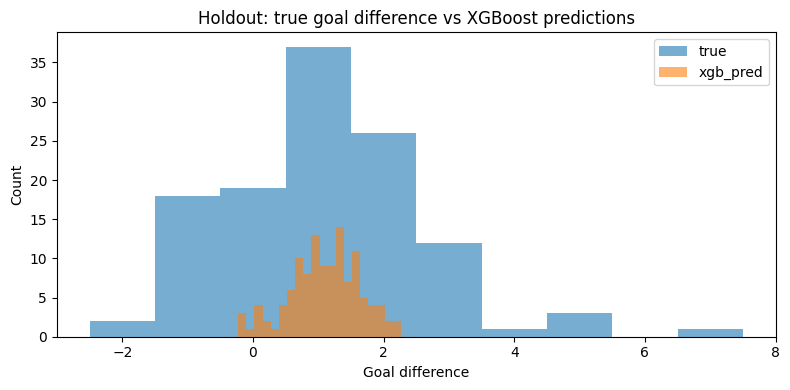

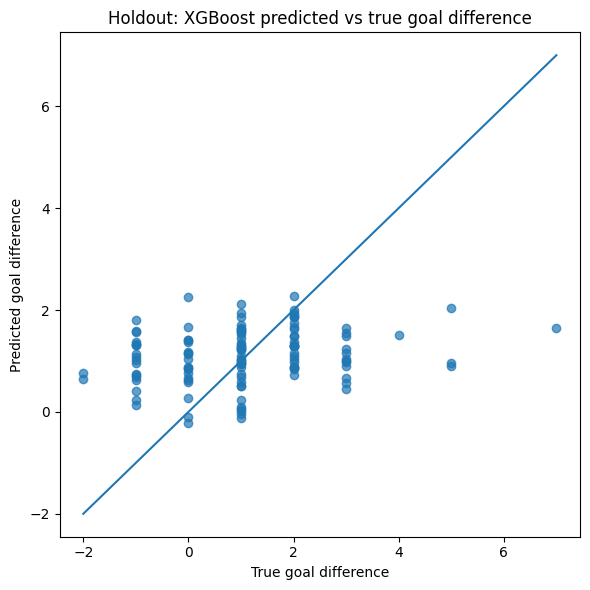

In [70]:
plt.figure(figsize=(8, 4))
plt.hist(
    y_holdout,
    bins=np.arange(y_holdout.min() - 0.5, y_holdout.max() + 1.5, 1),
    alpha=0.6,
    label="true",
)
plt.hist(xgb_holdout_pred, bins=20, alpha=0.6, label="xgb_pred")
plt.title("Holdout: true goal difference vs XGBoost predictions")
plt.xlabel("Goal difference")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("image/output6/holdout_xgb_hist.png")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_holdout, xgb_holdout_pred, alpha=0.7)
mn = min(y_holdout.min(), xgb_holdout_pred.min())
mx = max(y_holdout.max(), xgb_holdout_pred.max())
plt.plot([mn, mx], [mn, mx])
plt.title("Holdout: XGBoost predicted vs true goal difference")
plt.xlabel("True goal difference")
plt.ylabel("Predicted goal difference")
plt.tight_layout()
plt.savefig("image/output6/holdout_xgb_scatter.png")
plt.show()

## 10. Save for next step

In [71]:
part6_objects = {
    "xgb_search": xgb_search,
    "best_xgb": best_xgb,
    "xgb_cv": xgb_cv,
    "xgb_holdout_pred": xgb_holdout_pred,
    "comparison": comparison,
}

print("Part 6 completed successfully.")

Part 6 completed successfully.


## Interpretation

XGBoost is the **best model in cross-validation**, but **not the best on holdout**.

### CV performance

* **Ridge CV MAE:** `1.1608`
* **RF CV MAE:** `1.1017`
* **XGB CV MAE:** `1.0769`

and similarly for RMSE:

* Ridge: `1.5691`
* RF: `1.5016`
* XGB: `1.4346`

So on the training-era LOTO validation, XGBoost is clearly the strongest regressor.

### Holdout performance

* **Ridge holdout MAE:** `1.1535`
* **RF holdout MAE:** `1.1397`
* **XGB holdout MAE:** `1.1451`
* **Ridge holdout RMSE:** `1.4837`
* **RF holdout RMSE:** `1.4707`
* **XGB holdout RMSE:** `1.4903`

So on holdout:

* Random Forest is slightly best
* XGBoost is not terrible, but it does **not** convert its CV advantage into the best unseen performance

This suggests that XGBoost is learning more structure than Ridge or RF on the older tournaments, but that extra flexibility is not generalizing cleanly to 2018+2022. That is the kind of pattern I would describe as mild overfitting and instability from small sample size with temporal shift across tournaments.

However, XGBoost still has one important advantage. Unlike Random Forest, XGBoost produces a somewhat wider range:

* `pred_min = -0.226`
* `pred_max = 2.265`
* `pred_std = 0.530`

That is still compressed, but less pathological than RF, which never went negative on holdout.

So even though XGBoost is not the best pure regressor on holdout MAE/RMSE, it is still the **best candidate for threshold-based 3-class recovery**.

### Conclusion

* **Ridge:** too linear, too compressed
* **Random Forest:** modest improvement, but still narrow and not clearly better than naive baseline
* **XGBoost:** best CV regressor, but holdout gains do not fully materialize

### Next Step

I think the right move is to threshold-tune **XGBoost**, not Random Forest, because if any regression model has a chance of converting into a usable 3-class predictor, it is XGBoost. This helps answer the original project question more directly: does regression on score difference work as an alternative to direct classification?

# Part 7 — Threshold tuning for XGBoost

This is parallel to our Ridge threshold tuning, but using XGBoost predictions.

## 1. Pull objects

In [72]:
if "part6_objects" not in globals():
    raise ValueError("part6_objects not found. Please run Part 6 first.")
if "regression_objects_clean" not in globals():
    raise ValueError("regression_objects_clean not found. Please run Part 2.5 first.")

best_xgb = part6_objects["best_xgb"]

X_train = regression_objects_clean["X_train"].copy()
y_train = regression_objects_clean["y_train"].copy()
year_train = regression_objects_clean["year_train"].copy()

X_holdout = regression_objects_clean["X_holdout"].copy()
y_holdout = regression_objects_clean["y_holdout"].copy()
year_holdout = regression_objects_clean["year_holdout"].copy()

logo = LeaveOneGroupOut()

## 2. Helper functions

In [73]:
def diff_to_y3_from_true(x):
    if x > 0:
        return 2
    elif x == 0:
        return 1
    else:
        return 0


def pred_to_y3(pred, threshold):
    pred = np.asarray(pred)
    return np.where(pred > threshold, 2, np.where(pred < -threshold, 0, 1))


y_train_cls = np.array([diff_to_y3_from_true(v) for v in y_train])
y_holdout_cls = np.array([diff_to_y3_from_true(v) for v in y_holdout])

## 3. Generate OOF predictions

In [74]:
oof_pred = np.empty(len(X_train), dtype=float)

for fold, (tr_idx, va_idx) in enumerate(
    logo.split(X_train, y_train, groups=year_train), start=1
):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr = y_train.iloc[tr_idx]

    fold_model = clone(best_xgb)
    fold_model.fit(X_tr, y_tr)
    oof_pred[va_idx] = fold_model.predict(X_va)

print("OOF prediction summary:")
print(pd.Series(oof_pred).describe())

OOF prediction summary:
count    244.000000
mean       1.040510
std        0.532071
min       -0.533155
25%        0.704674
50%        1.059562
75%        1.370160
max        3.143651
dtype: float64


## 4. Threshold search

In [75]:
threshold_grid = np.round(np.arange(0.05, 1.55, 0.05), 2)

rows = []
for t in threshold_grid:
    pred_cls = pred_to_y3(oof_pred, threshold=t)

    rows.append(
        {
            "threshold": t,
            "accuracy": accuracy_score(y_train_cls, pred_cls),
            "macro_f1": f1_score(y_train_cls, pred_cls, average="macro"),
            "weighted_f1": f1_score(y_train_cls, pred_cls, average="weighted"),
            "pred_draw_rate": np.mean(pred_cls == 1),
            "pred_fav_win_rate": np.mean(pred_cls == 2),
            "pred_fav_loss_rate": np.mean(pred_cls == 0),
        }
    )

threshold_results = pd.DataFrame(rows)
threshold_ranked = threshold_results.sort_values(
    ["macro_f1", "accuracy"], ascending=[False, False]
).reset_index(drop=True)

best_threshold = threshold_ranked.loc[0, "threshold"]

print("Selected threshold:", best_threshold)
print("\nTop 15 threshold candidates by OOF macro F1:")
print(threshold_ranked.head(15))

Selected threshold: 0.95

Top 15 threshold candidates by OOF macro F1:
    threshold  accuracy  macro_f1  weighted_f1  pred_draw_rate  \
0        0.95  0.598361  0.382673     0.582345        0.389344   
1        1.00  0.590164  0.382514     0.578070        0.418033   
2        1.10  0.561475  0.381905     0.555304        0.520492   
3        0.75  0.631148  0.378934     0.594048        0.270492   
4        1.05  0.561475  0.374155     0.555607        0.479508   
5        0.80  0.618852  0.372144     0.586046        0.286885   
6        0.85  0.606557  0.368694     0.579261        0.311475   
7        0.90  0.590164  0.362988     0.569161        0.340164   
8        0.70  0.627049  0.358095     0.582998        0.233607   
9        1.15  0.512295  0.353105     0.513148        0.577869   
10       1.20  0.508197  0.352016     0.511120        0.598361   
11       0.65  0.622951  0.338171     0.570833        0.200820   
12       0.50  0.639344  0.336171     0.573912        0.151639   
13   

## 5. Fit full train and predict holdout

In [76]:
xgb_final = clone(best_xgb)
xgb_final.fit(X_train, y_train)
holdout_pred_cont = xgb_final.predict(X_holdout)

holdout_pred_cls = pred_to_y3(holdout_pred_cont, threshold=best_threshold)

## 6. Holdout classification metrics

In [77]:
holdout_acc = accuracy_score(y_holdout_cls, holdout_pred_cls)
holdout_macro_f1 = f1_score(y_holdout_cls, holdout_pred_cls, average="macro")
holdout_weighted_f1 = f1_score(y_holdout_cls, holdout_pred_cls, average="weighted")
cm = confusion_matrix(y_holdout_cls, holdout_pred_cls, labels=[0, 1, 2])

print("Holdout classification metrics from XGB + threshold:")
print(
    {
        "threshold": best_threshold,
        "accuracy": holdout_acc,
        "macro_f1": holdout_macro_f1,
        "weighted_f1": holdout_weighted_f1,
    }
)

print(
    "\nHoldout confusion matrix (rows=true, cols=pred) with label order [0=fav_loss, 1=draw, 2=fav_win]:"
)
print(cm)

print("\nClassification report:")
print(
    classification_report(
        y_holdout_cls,
        holdout_pred_cls,
        labels=[0, 1, 2],
        target_names=["fav_loses", "draw", "fav_wins"],
        digits=4,
    )
)

dist_compare = (
    pd.DataFrame(
        {
            "true_count": pd.Series(y_holdout_cls).value_counts().sort_index(),
            "pred_count": pd.Series(holdout_pred_cls).value_counts().sort_index(),
        }
    )
    .fillna(0)
    .astype(int)
)

dist_compare.index = ["fav_loses", "draw", "fav_wins"]

print("\nHoldout class distribution comparison:")
print(dist_compare)

Holdout classification metrics from XGB + threshold:
{'threshold': np.float64(0.95), 'accuracy': 0.5630252100840336, 'macro_f1': 0.35132783404684836, 'weighted_f1': 0.5404931106827193}

Holdout confusion matrix (rows=true, cols=pred) with label order [0=fav_loss, 1=draw, 2=fav_win]:
[[ 0  9 11]
 [ 0 10  9]
 [ 0 23 57]]

Classification report:
              precision    recall  f1-score   support

   fav_loses     0.0000    0.0000    0.0000        20
        draw     0.2381    0.5263    0.3279        19
    fav_wins     0.7403    0.7125    0.7261        80

    accuracy                         0.5630       119
   macro avg     0.3261    0.4129    0.3513       119
weighted avg     0.5357    0.5630    0.5405       119


Holdout class distribution comparison:
           true_count  pred_count
fav_loses          20           0
draw               19          42
fav_wins           80          77


C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yiyun\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## 7. Plot threshold curve

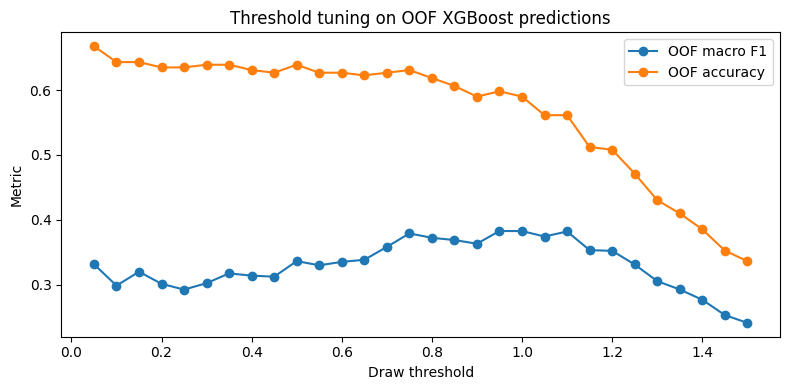

In [78]:
plot_df = threshold_results.sort_values("threshold").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["threshold"], plot_df["macro_f1"], marker="o", label="OOF macro F1")
plt.plot(plot_df["threshold"], plot_df["accuracy"], marker="o", label="OOF accuracy")
plt.title("Threshold tuning on OOF XGBoost predictions")
plt.xlabel("Draw threshold")
plt.ylabel("Metric")
plt.legend()
plt.tight_layout()
plt.savefig("image/output7/threshold_tuning_oof_xgb_predictions.png")
plt.show()

## 8. Plot holdout prediction histogram with threshold lines

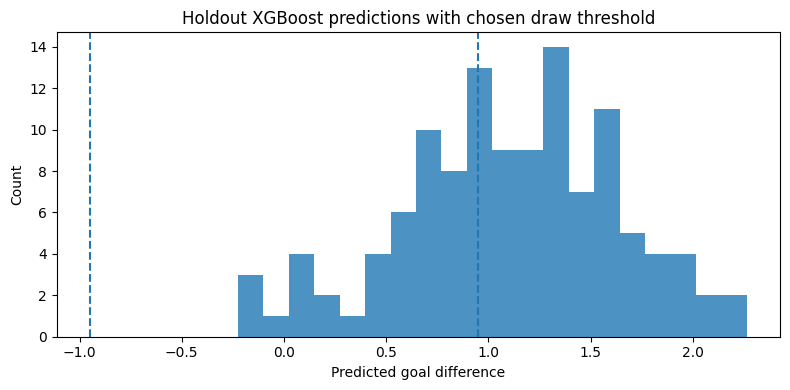

In [79]:
plt.figure(figsize=(8, 4))
plt.hist(holdout_pred_cont, bins=20, alpha=0.8)
plt.axvline(best_threshold, linestyle="--")
plt.axvline(-best_threshold, linestyle="--")
plt.title("Holdout XGBoost predictions with chosen draw threshold")
plt.xlabel("Predicted goal difference")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("image/output7/holdout_xgb_predictions_with_chosen_draw_threshold.png")
plt.show()

## 9. Save objects

In [80]:
part7_objects = {
    "threshold_results": threshold_results,
    "threshold_ranked": threshold_ranked,
    "best_threshold": best_threshold,
    "holdout_pred_cont": holdout_pred_cont,
    "holdout_pred_cls": holdout_pred_cls,
    "y_holdout_cls": y_holdout_cls,
    "confusion_matrix": cm,
    "holdout_accuracy": holdout_acc,
    "holdout_macro_f1": holdout_macro_f1,
    "holdout_weighted_f1": holdout_weighted_f1,
}

print("Part 7 completed successfully.")

Part 7 completed successfully.


## Interpretation

XGBoost + thresholding is **better than Ridge + thresholding**, but it still has the same fundamental failure mode.

### Best threshold

* selected threshold: **0.95**

That is much wider than Ridge's `0.50`, which means XGBoost needs a broader “draw band” to get its best 3-class performance.

### Holdout classification performance

* **accuracy:** `0.563`
* **macro F1:** `0.351`
* **weighted F1:** `0.540`

Compared with Ridge + threshold:

* Ridge accuracy: `0.580`
* Ridge macro F1: `0.298`

So XGBoost:

* **improves macro F1 materially**
* but **reduces accuracy slightly**

That tradeoff makes sense because XGBoost predicts many more draws.

## What improved

The biggest improvement is on the **draw class**.

For XGBoost:

* draw recall = **0.526**
* draw F1 = **0.328**

For Ridge:

* draw recall = **0.158**
* draw F1 = **0.140**

So XGBoost is clearly better at recovering draws.

## What still fails

The biggest problem remains unchanged:

* predicted **zero favored losses**

Confusion matrix:

$$
\begin{bmatrix}
0 & 9 & 11 \\
0 & 10 & 9 \\
0 & 23 & 57
\end{bmatrix}
$$

This means:

* true favored losses are being mapped to either draws or favored wins
* the model still never produces enough negative predictions to recover that class

That is the core reason the regression framing remains limited.

### Conclusion

1. **Score-difference regression is a valid alternative framing**
2. **Penalty shootout matches should be removed** for coherence
3. **Ridge** is too compressed and performs poorly
4. **Random Forest** improves continuous error slightly, but not convincingly
5. **XGBoost** is the strongest regression model overall
6. but even XGBoost + thresholding still **cannot recover favored losses**
7. therefore, for the actual 3-class task, **direct classification is more appropriate than regression**